# Estimating the Causal Effect of Extracurricular Activities on Student Performance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

# Clean, academic plotting defaults
ACADEMIC_PALETTE = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette=ACADEMIC_PALETTE,
    font="DejaVu Serif",
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.figsize": (7, 4.5),
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.titleweight": "bold",
        "axes.edgecolor": "0.25",
        "axes.linewidth": 0.8,
        "grid.color": "0.88",
        "grid.linewidth": 0.6,
        "lines.linewidth": 1.6,
        "patch.edgecolor": "0.25",
        "patch.linewidth": 0.6,
    },
)

def format_axes(ax=None, title=None, xlabel=None, ylabel=None, legend_title=None):
    """Apply final formatting for publication-style plots."""
    ax = ax or plt.gca()
    if title is not None:
        ax.set_title(title, pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if ax.get_legend() is not None:
        ax.legend(title=legend_title, frameon=False)
    sns.despine(ax=ax, trim=True)
    return ax

# maximize display of columns
pd.set_option('display.max_columns', None)

# Data

load the data and get a basic understanding of what the data looks like.
Based on the description on kaggle: https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis/data

Overall, we have 6,607 student observations and 20 columns. Our target column is **Exam_score**, treatment column is **Extracurricular\_Activities**  and remaining 18 columns are potential covariates.

+ 13 columns are categorical variables (10 for multi-category variables and 3 for binary variables): Parental\_Involvement, Access\_to\_Resources, Extracurricular\_Activities, Motivation\_Level, Internet\_Access, Family\_Income, Teacher\_Quality, School\_Type, Peer_Influence, Parental_Education_Level, Learning_Disabilities, Distance_from_Home, Gender

+ 6 columns are continous variables: Hours_Studied, Attendance (attendance percentage), Sleep_Hours (average sleep hours), Physical_Activity, Tutoring_Sessions(number of tutoring sessions), Previous_Scores(past academic scores)

In [2]:
raw_data = pd.read_csv('../data/StudentPerformanceFactors.csv')

In [3]:
raw_data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
raw_data.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [5]:
# basic data descriptions
raw_data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
raw_data.select_dtypes(include=np.number).columns.tolist()

['Hours_Studied',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity',
 'Exam_Score']

In [7]:
continuous_vars = raw_data.select_dtypes(include=np.number).columns.tolist()
categorical_vars = raw_data.select_dtypes(exclude=np.number).columns.tolist()

In [8]:
len(continuous_vars), len(categorical_vars)

(7, 13)

In [9]:
cont_summary = raw_data[continuous_vars].agg(['mean', 'std', 'min', 'max']).T
cont_summary = cont_summary.round(3)
# add null rate
cont_summary['null_count'] = raw_data[continuous_vars].isnull().sum()
cont_summary['null_rate'] = raw_data[continuous_vars].isnull().mean().round(3)


cont_summary.reset_index(inplace=True)
cont_summary.rename(columns={'index': 'Variable'}, inplace=True)
cont_summary

,Variable,mean,std,min,max,null_count,null_rate
0,Hours_Studied,19.975,5.991,1.0,44.0,0,0.0
1,Attendance,79.977,11.547,60.0,100.0,0,0.0
2,Sleep_Hours,7.029,1.468,4.0,10.0,0,0.0
3,Previous_Scores,75.071,14.400,50.0,100.0,0,0.0
4,Tutoring_Sessions,1.494,1.231,0.0,8.0,0,0.0
5,Physical_Activity,2.968,1.031,0.0,6.0,0,0.0
6,Exam_Score,67.236,3.890,55.0,101.0,0,0.0


In [10]:
cat_summary_list = []

for col in categorical_vars:
    counts = raw_data[col].value_counts(dropna=False)
    
    summary = {
        "Variable": col,
        "Num_Categories": raw_data[col].nunique(dropna=False),
        "Categories": ", ".join(map(str, raw_data[col].dropna().unique())),
        "Mode": counts.idxmax(),
        'Null_Count': counts.get(np.nan, 0),
        'Null_Rate': counts.get(np.nan, 0) / len(raw_data)
    }
    
    cat_summary_list.append(summary)

cat_summary = pd.DataFrame(cat_summary_list)

cat_summary

,Variable,Num_Categories,Categories,Mode,Null_Count,Null_Rate
0,Parental_Involvement,3,"Low, Medium, High",Medium,0,0.000000
1,Access_to_Resources,3,"High, Medium, Low",Medium,0,0.000000
2,Extracurricular_Activities,2,"No, Yes",Yes,0,0.000000
3,Motivation_Level,3,"Low, Medium, High",Medium,0,0.000000
4,Internet_Access,2,"Yes, No",Yes,0,0.000000
5,Family_Income,3,"Low, Medium, High",Low,0,0.000000
6,Teacher_Quality,4,"Medium, High, Low",Medium,78,0.011806
7,School_Type,2,"Public, Private",Public,0,0.000000
8,Peer_Influence,3,"Positive, Negative, Neutral",Positive,0,0.000000
9,Learning_Disabilities,2,"No, Yes",No,0,0.000000


Comment: 

although we have 13 categorical variables in our dataset, each of them has less than 5 categories which will not result in dimension problems if we use one-hot encoding.

Also, we have some missing values in our dataset but only 1\% in each column.

In [11]:
# continuous
cont_summary.to_latex(index=False, float_format="%.3f")

# # categorical
cat_summary.to_latex(index=False)

'\\begin{tabular}{lrllrr}\n\\toprule\nVariable & Num_Categories & Categories & Mode & Null_Count & Null_Rate \\\\\n\\midrule\nParental_Involvement & 3 & Low, Medium, High & Medium & 0 & 0.000000 \\\\\nAccess_to_Resources & 3 & High, Medium, Low & Medium & 0 & 0.000000 \\\\\nExtracurricular_Activities & 2 & No, Yes & Yes & 0 & 0.000000 \\\\\nMotivation_Level & 3 & Low, Medium, High & Medium & 0 & 0.000000 \\\\\nInternet_Access & 2 & Yes, No & Yes & 0 & 0.000000 \\\\\nFamily_Income & 3 & Low, Medium, High & Low & 0 & 0.000000 \\\\\nTeacher_Quality & 4 & Medium, High, Low & Medium & 78 & 0.011806 \\\\\nSchool_Type & 2 & Public, Private & Public & 0 & 0.000000 \\\\\nPeer_Influence & 3 & Positive, Negative, Neutral & Positive & 0 & 0.000000 \\\\\nLearning_Disabilities & 2 & No, Yes & No & 0 & 0.000000 \\\\\nParental_Education_Level & 4 & High School, College, Postgraduate & High School & 90 & 0.013622 \\\\\nDistance_from_Home & 4 & Near, Moderate, Far & Near & 67 & 0.010141 \\\\\nGender & 2

In [12]:
with open("../results/cont_summary.tex", "w") as f:
    f.write(cont_summary.to_latex(index=False, float_format="%.3f"))

with open("../results/cat_summary.tex", "w") as f:
    f.write(cat_summary.to_latex(index=False))

In [13]:
raw_data.isnull().sum(axis=1).sum()/ raw_data.shape[0]

np.float64(0.035568336612683514)

Overall, we have 4\% data containing any missing values in any variable. Since the rate is very small, we can safely drop the rows containing any missing values.

In [14]:
data = raw_data.dropna()

In [15]:
data.shape

(6378, 20)

Finally, we have 6378 rows and 20 columns.


## EDA

### Outcome variable

What is the distribution of outcome (Exam_score)?

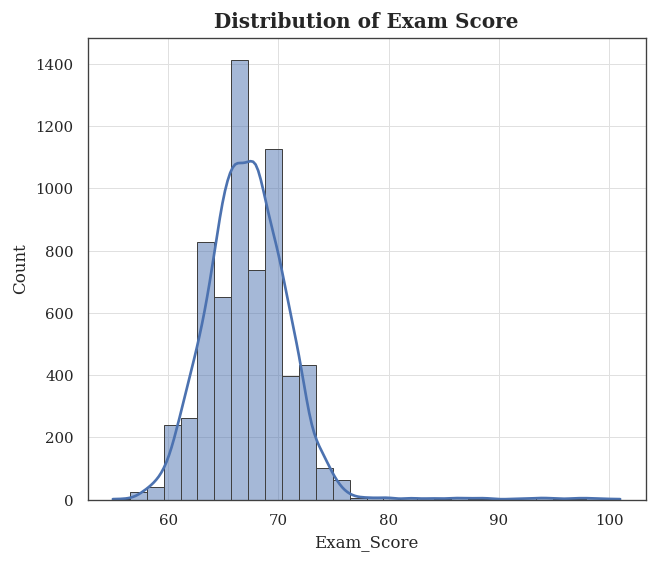

In [16]:
plt.figure(figsize=(6, 5))
sns.histplot(data["Exam_Score"], bins=30, kde=True)
plt.title("Distribution of Exam Score")
plt.savefig('../figs/dist_scores.png')
plt.show()

Comment: the distribution of exam score is mainly centered around 75-70 and a little bit right skewed.

### Treatment variable

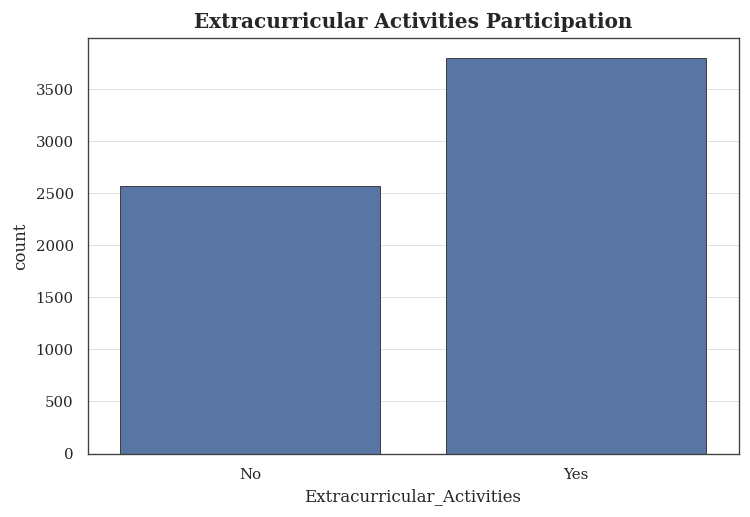

In [17]:
data['Extracurricular_Activities'].value_counts(normalize=True)
sns.countplot(x='Extracurricular_Activities', data=data)
plt.title("Extracurricular Activities Participation")
plt.savefig('../figs/dis_extra_act.png')
plt.show()

Comment: the distribution of extracurricular_activities is not too imbalanced which gives us basic support to do the downstream regression otherwise the inference has a higher risk of instability.

### Outcome vs Treatment

In [18]:
# naive difference in means
treatment_mean = data[data['Extracurricular_Activities'] == 'Yes']['Exam_Score'].mean()
control_mean = data[data['Extracurricular_Activities'] == 'No']['Exam_Score'].mean()
diff_in_means = treatment_mean - control_mean
print(f"Difference in means: {diff_in_means:.3f}")

Difference in means: 0.503


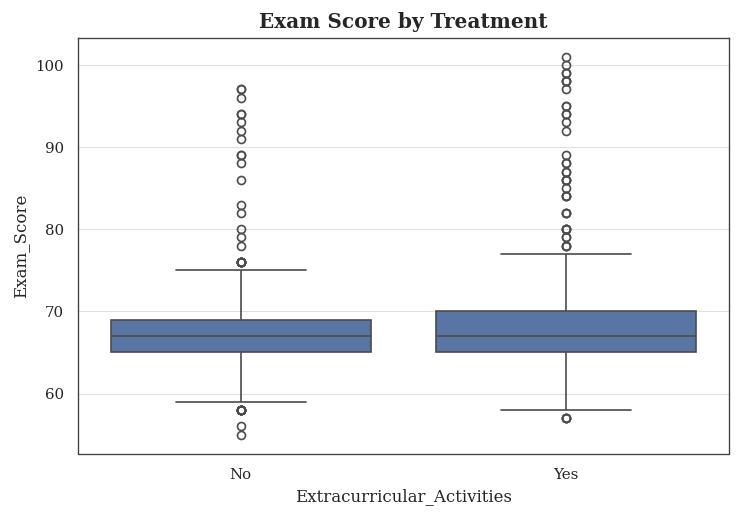

In [19]:
sns.boxplot(x="Extracurricular_Activities", y="Exam_Score", data=data)
plt.title("Exam Score by Treatment")
plt.show()

Comment: In a very basic level, the students who take the extra-curricular activities have 0.503 higher mean score than those who don't.

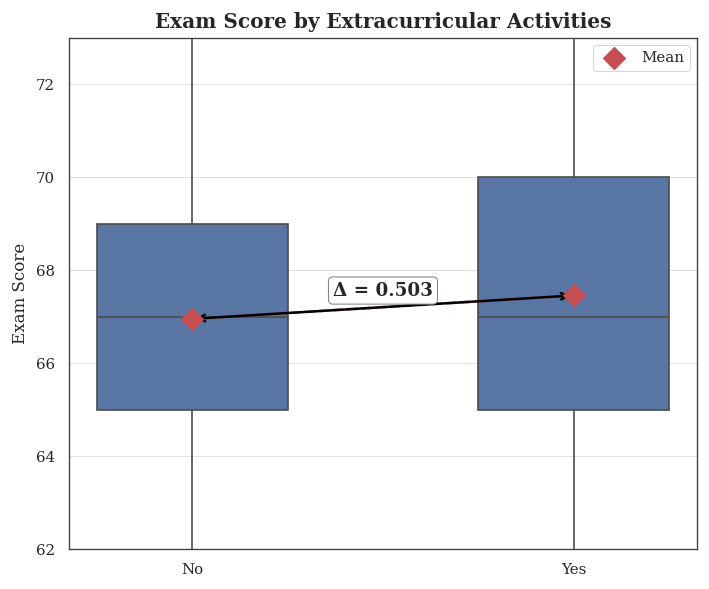

In [20]:
plt.figure(figsize=(6, 5))

# boxplot
ax = sns.boxplot(
    x="Extracurricular_Activities",
    y="Exam_Score",
    data=data,
    width=0.5,
    showfliers=False   # hide extreme outliers for clarity
)

# mean points
means = data.groupby("Extracurricular_Activities")["Exam_Score"].mean()

plt.scatter(
    [0, 1],
    means.values,
    color="#C44E52",
    marker="D",
    s=90,
    zorder=5,
    label="Mean"
)

# connect means
plt.plot(
    [0, 1],
    means.values,
    color="#C44E52",
    linestyle="--",
    alpha=0.8
)

# annotate mean difference
mid_y = means.mean() + 0.25

plt.annotate(
    "",
    xy=(0, means.iloc[0]),
    xytext=(1, means.iloc[1]),
    arrowprops=dict(
        arrowstyle="<->",
        color="black",
        lw=1.5
    )
)

plt.text(
    0.5,
    mid_y,
    f"Δ = {diff_in_means:.3f}",
    ha="center",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray")
)

# zoom y-axis slightly
plt.ylim(62, 73)

plt.title("Exam Score by Extracurricular Activities")
plt.xlabel("")
plt.ylabel("Exam Score")

plt.legend(frameon=True)
plt.tight_layout()
plt.savefig('../figs/boxplot_diff_means_naive.png')
plt.show()

### Confounding

Try to find potential confounders in a visualization form

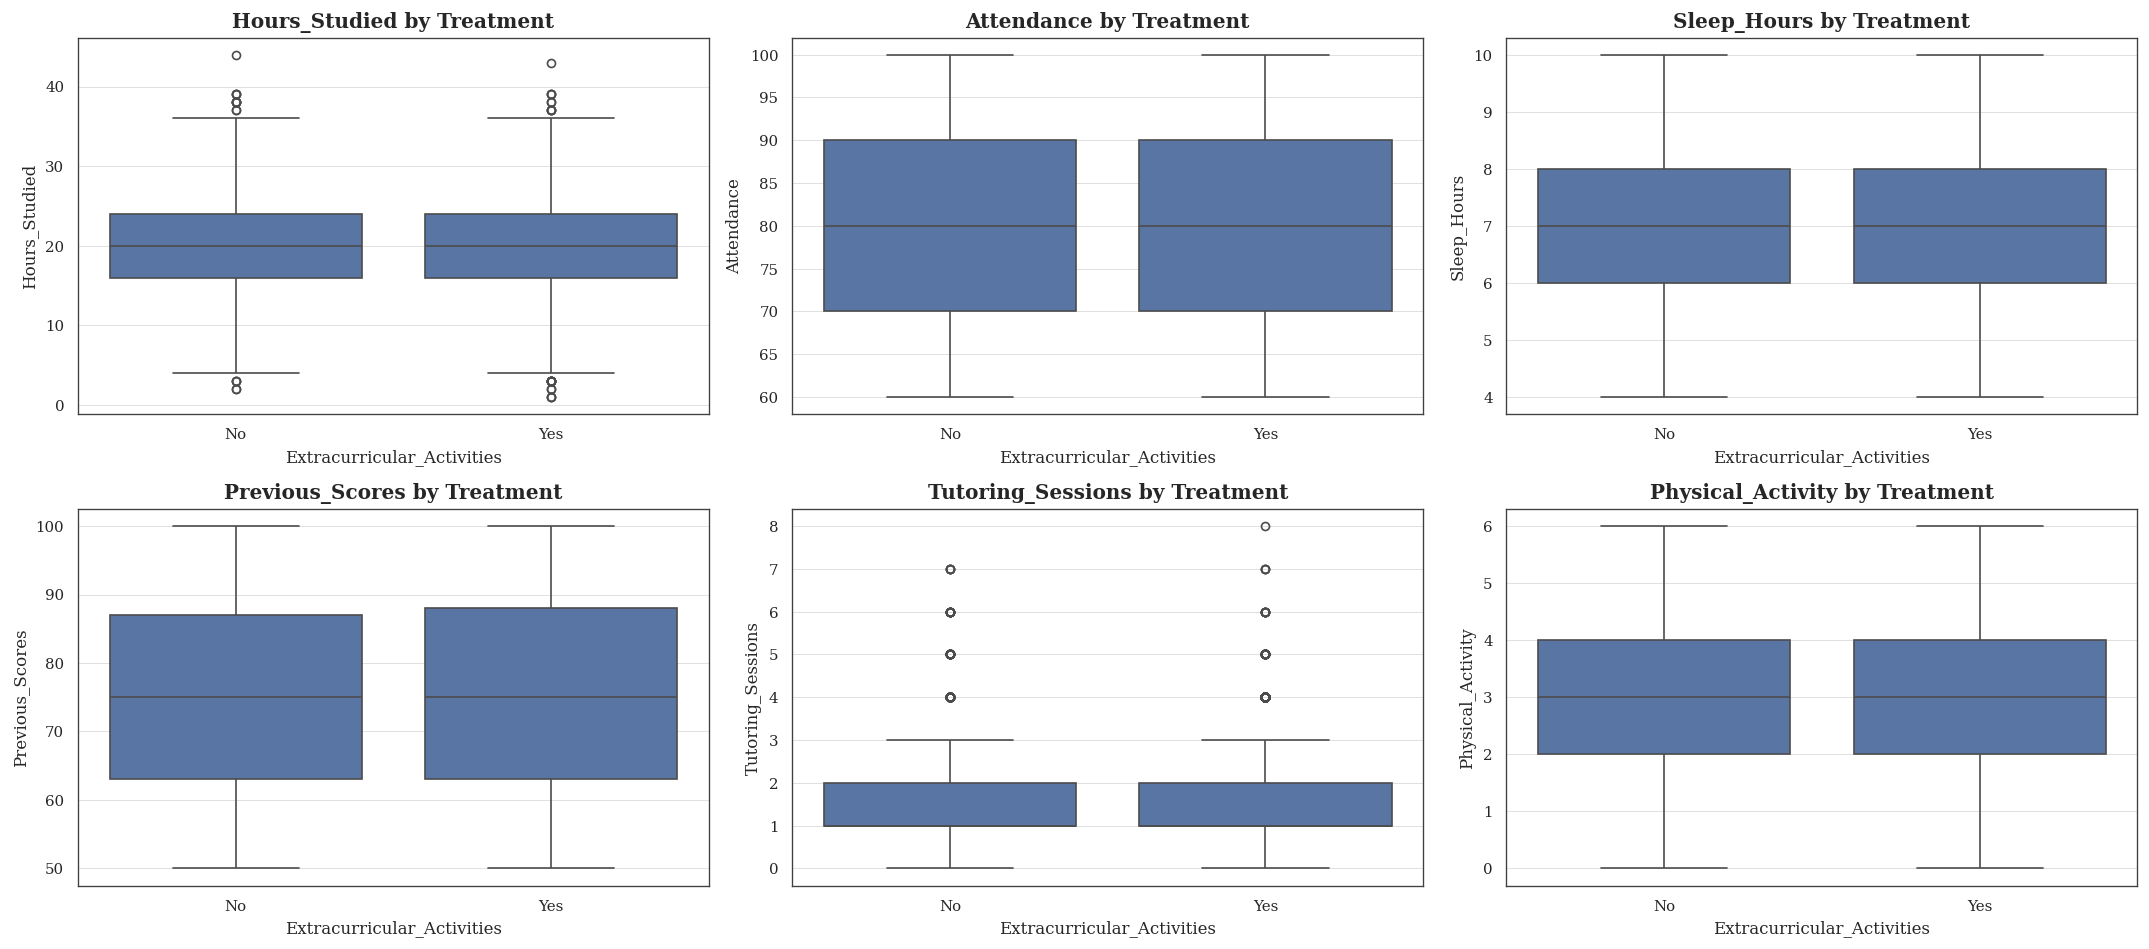

In [21]:
con_vars_to_plot = [col for col in continuous_vars if col != 'Exam_Score']  # covariates only

n_cols = 3
n_rows = int(np.ceil(len(con_vars_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(con_vars_to_plot):
    sns.boxplot(x='Extracurricular_Activities', y=col, data=data, ax=axes[i])
    axes[i].set_title(f"{col} by Treatment")

# hide unused subplots
for j in range(len(con_vars_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

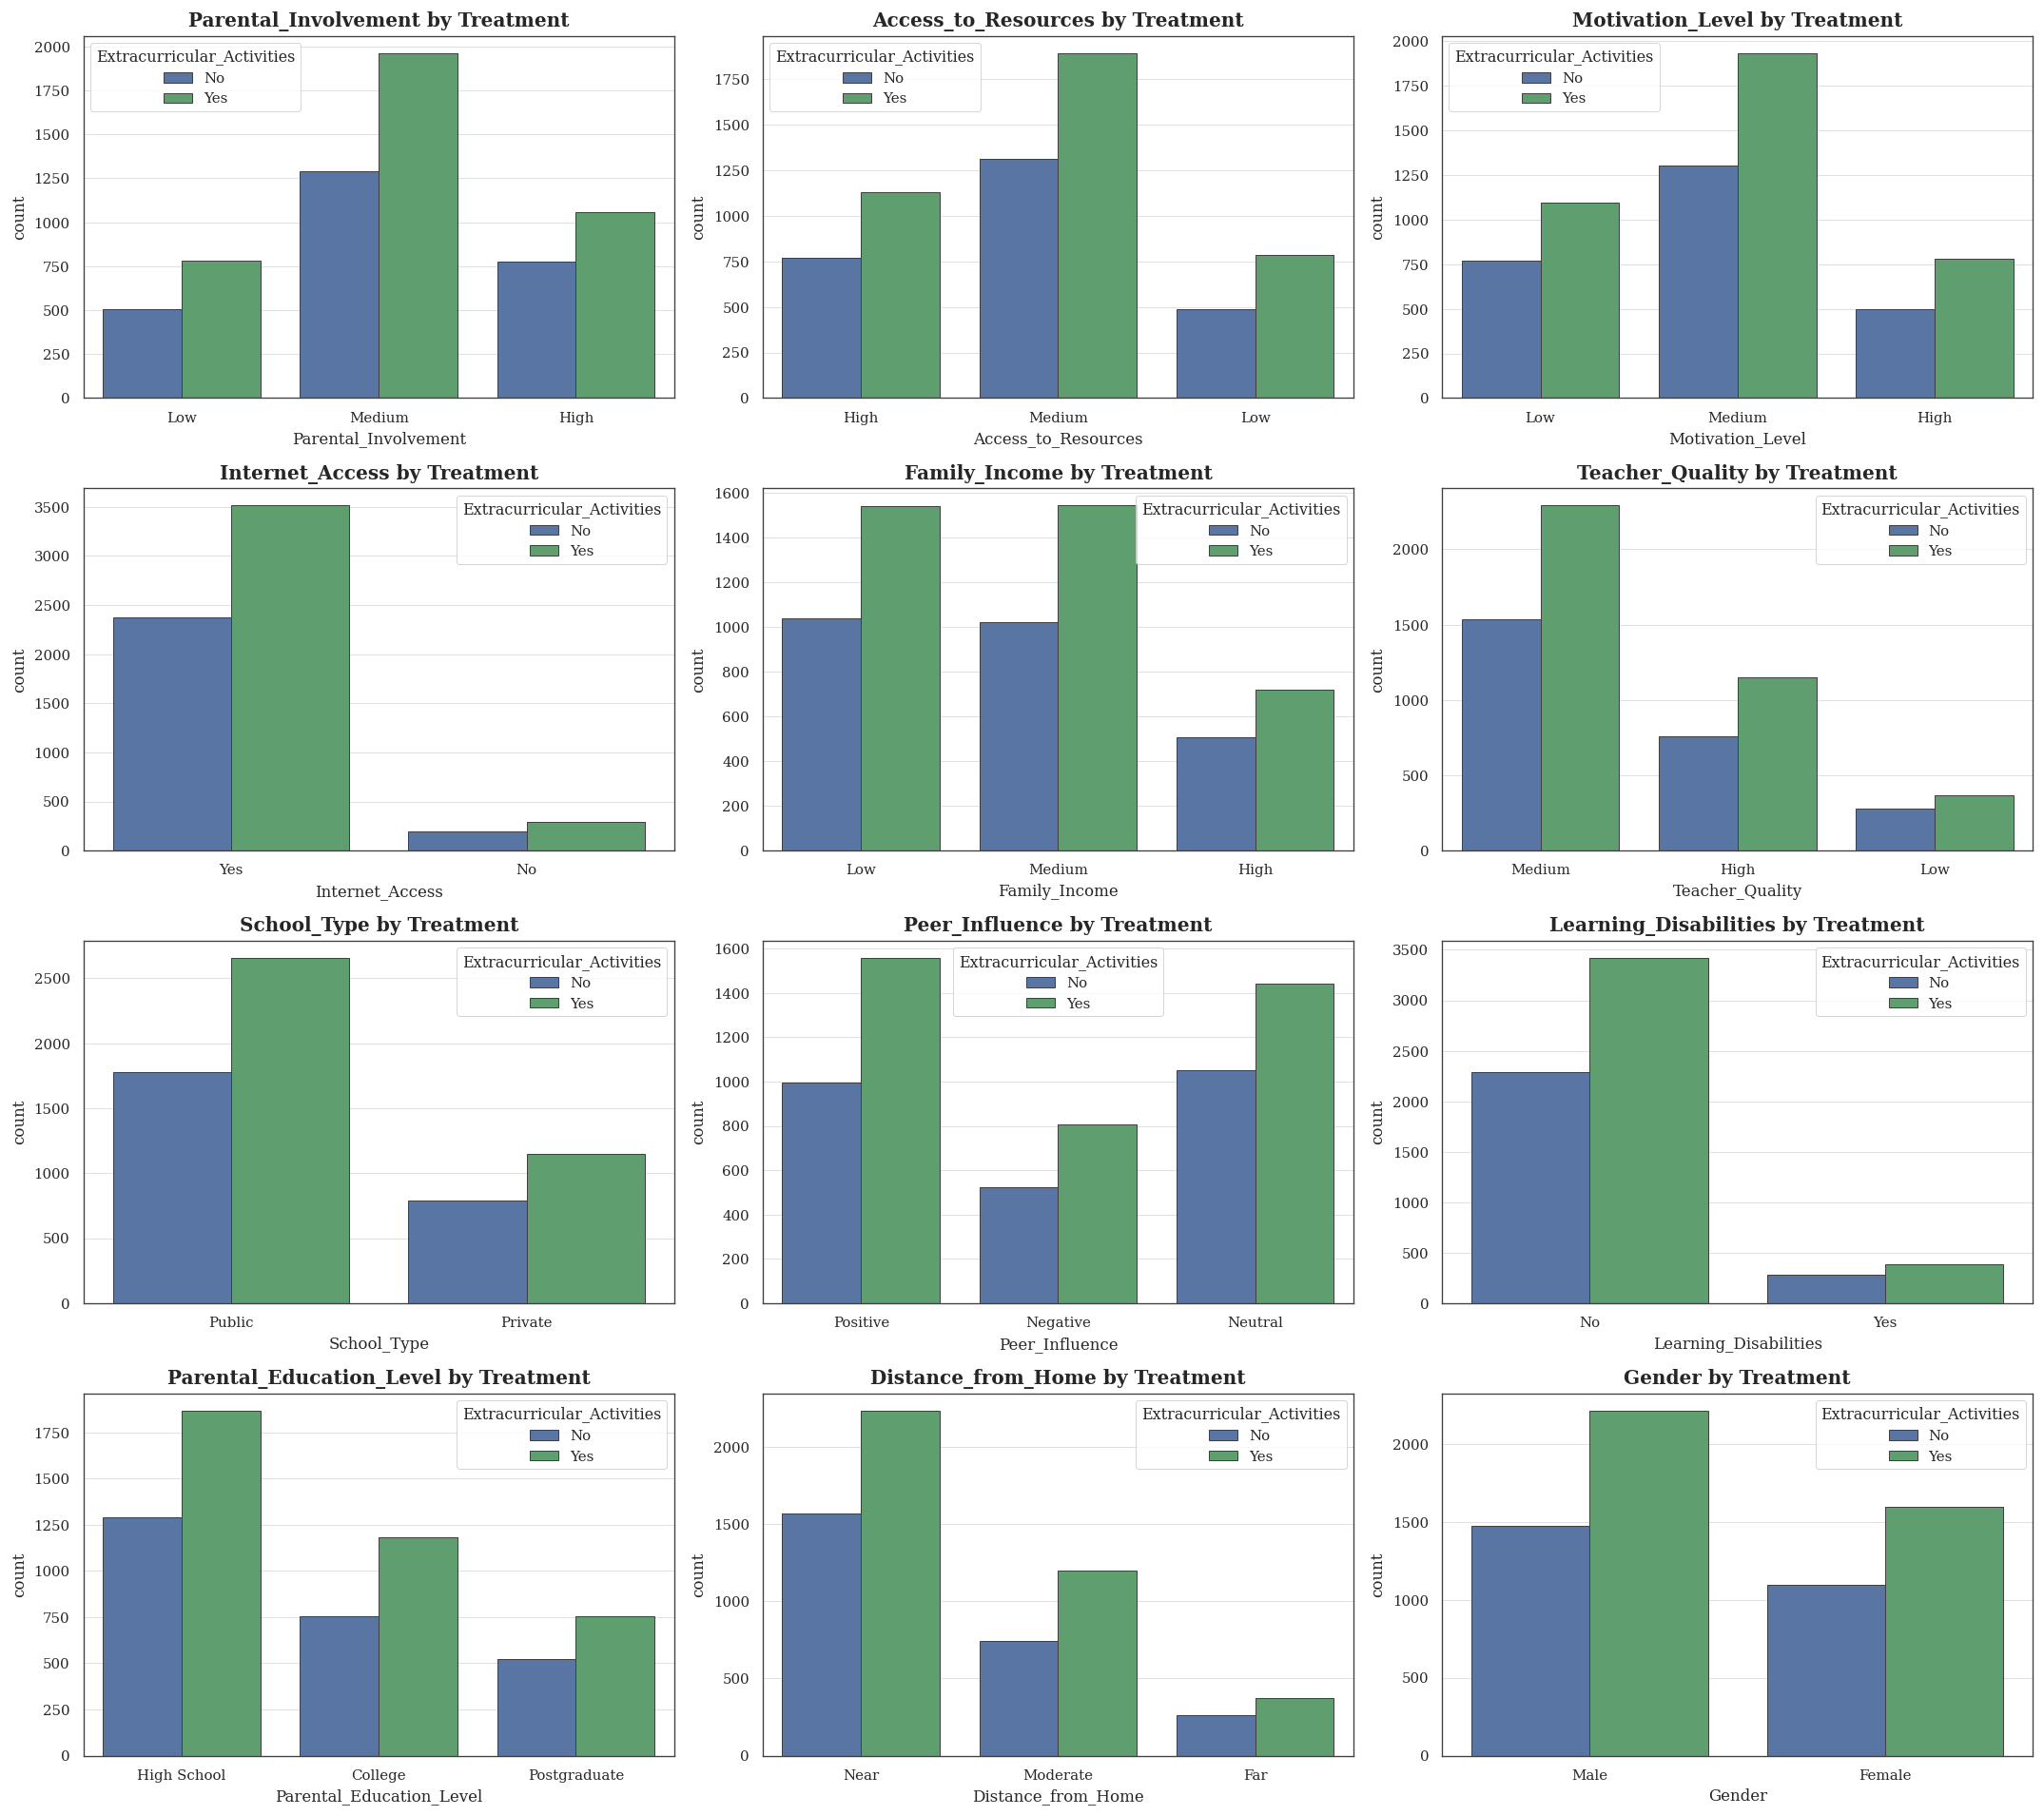

In [22]:
cat_vars_to_plot = [col for col in categorical_vars if col != 'Extracurricular_Activities']  # covariates only

n_cols = 3
n_rows = int(np.ceil(len(cat_vars_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cat_vars_to_plot):
    sns.countplot(x=col, hue='Extracurricular_Activities', data=data, ax=axes[i])
    axes[i].set_title(f"{col} by Treatment")

# hide unused subplots
for j in range(len(cat_vars_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Comment:

From the above visualization, several categorical variables are highly likely to be candidate confounders while I observe minor difference in the distribution of continous variables between subgroups

### Correlation

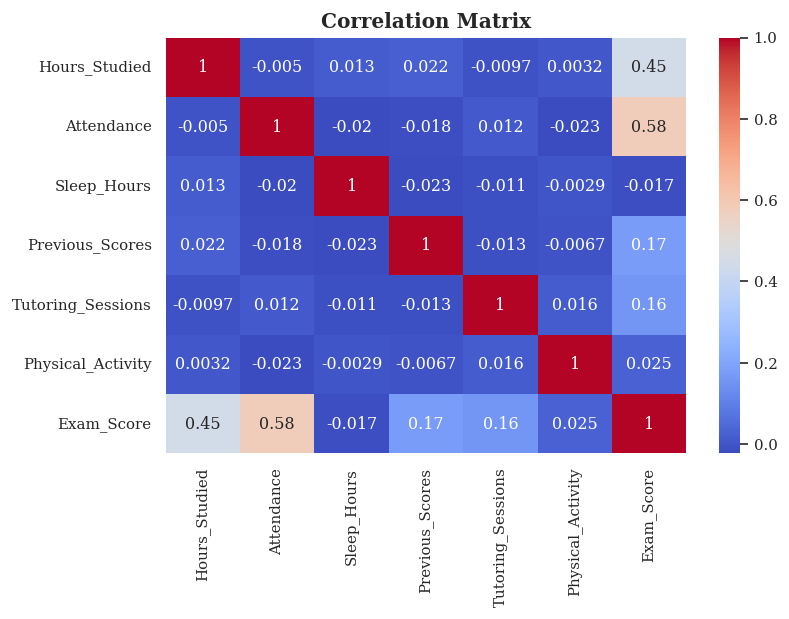

In [23]:
corr = data[continuous_vars].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Comment: among all the continuous variables, I don't see severe multicollinearity.

### SMD


I use standardized mean difference to quantitvely find the potential confounders. For categorical variables, I first do one-hot encoding and then calculate the SMD.

In [24]:
Y_COL = 'Exam_Score'
T_COL = 'Extracurricular_Activities'
NUM_CONVARS = [col for col in continuous_vars if col != Y_COL]
CAT_CONVARS = [col for col in categorical_vars if col != T_COL]

In [25]:
NUM_CONVARS, CAT_CONVARS

(['Hours_Studied',
  'Attendance',
  'Sleep_Hours',
  'Previous_Scores',
  'Tutoring_Sessions',
  'Physical_Activity'],
 ['Parental_Involvement',
  'Access_to_Resources',
  'Motivation_Level',
  'Internet_Access',
  'Family_Income',
  'Teacher_Quality',
  'School_Type',
  'Peer_Influence',
  'Learning_Disabilities',
  'Parental_Education_Level',
  'Distance_from_Home',
  'Gender'])

In [26]:
# treatment mapping
data['Extracurricular_Activities'] = data['Extracurricular_Activities'].map({'Yes': 1, 'No': 0})

/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_3431/2756597950.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Extracurricular_Activities'] = data['Extracurricular_Activities'].map({'Yes': 1, 'No': 0})


In [27]:
def compute_smd_binary(df, treatment, cols):
    smd = []
    for col in cols:
        treated = df[df[treatment] == 1][col]
        control = df[df[treatment] == 0][col]

        p1 = treated.mean()
        p0 = control.mean()

        pooled = np.sqrt((p1*(1-p1) + p0*(1-p0)) / 2)
        smd.append((p1 - p0) / pooled if pooled != 0 else 0)

    return pd.DataFrame({"variable": cols, "SMD": smd})
# one-hot encode categorical variables

data_cat_dummies = pd.get_dummies(data, columns=categorical_vars, drop_first=True)

# combine with treatment
data_cat_dummies = pd.concat([data[[T_COL]], data_cat_dummies], axis=1)

smd_cat = compute_smd_binary(data_cat_dummies, 
                             T_COL, 
                             [col for col in data_cat_dummies.columns if col not in [T_COL]])

/var/folders/4l/rnbg3z_9549618f5h72zn7040000gn/T/ipykernel_3431/2762943806.py:10: RuntimeWarning: invalid value encountered in sqrt
  pooled = np.sqrt((p1*(1-p1) + p0*(1-p0)) / 2)


In [28]:
def compute_smd_con(df, treatment, cols):
    smd = []
    for col in cols:
        treated = df[df[treatment] == 1][col]
        control = df[df[treatment] == 0][col]

        mean_diff = treated.mean() - control.mean()
        pooled_std = np.sqrt((treated.var() + control.var()) / 2)

        smd.append(mean_diff / pooled_std if pooled_std != 0 else 0)

    return pd.DataFrame({"variable": cols, "SMD": smd})

# continuous variables
smd_con = compute_smd_con(data, T_COL, NUM_CONVARS)
smd_con.head()

,variable,SMD
0,Hours_Studied,-0.017103
1,Attendance,-0.003571
2,Sleep_Hours,0.006174
3,Previous_Scores,0.005440
4,Tutoring_Sessions,0.012883


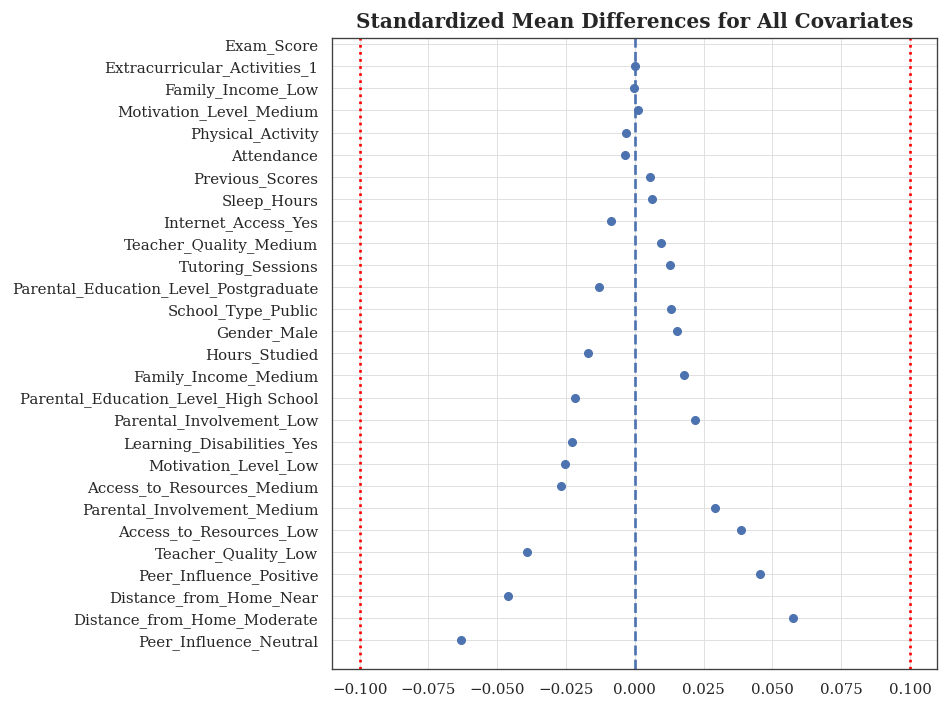

In [29]:
smd_all = pd.concat([smd_con, smd_cat])
# show top k imbalanced covariates
smd_all['abs_SMD'] = smd_all['SMD'].abs()
smd_all = smd_all.sort_values('abs_SMD', ascending=False).drop(columns='abs_SMD')
plt.figure(figsize=(8,6))
plt.scatter(smd_all["SMD"], smd_all["variable"])

plt.axvline(0, linestyle="--")
plt.axvline(0.1, linestyle=":", color="red")
plt.axvline(-0.1, linestyle=":", color="red")

plt.title("Standardized Mean Differences for All Covariates")
plt.tight_layout()
plt.savefig('../figs/smd_all.png')
plt.show()

In [30]:
smd_all.head(10)

,variable,SMD
20,Peer_Influence_Neutral,-0.063044
25,Distance_from_Home_Moderate,0.057411
26,Distance_from_Home_Near,-0.046266
21,Peer_Influence_Positive,0.045439
17,Teacher_Quality_Low,-0.039075
9,Access_to_Resources_Low,0.038506
8,Parental_Involvement_Medium,0.029321
10,Access_to_Resources_Medium,-0.026659
12,Motivation_Level_Low,-0.025210
22,Learning_Disabilities_Yes,-0.022762


# Outcome regression

\begin{equation*}
Y_i  = \alpha_0 + \alpha_1 T_i + X_i^T \alpha + \epsilon_i
\end{equation*}

Here, $\alpha_1$ represents the estimated average treatment effect of extra-curricular activities on exam scores, controlling for the covariates $X_i$. We will fit this model using ordinary least squares (OLS) regression.


In [31]:
# helper function

def make_formula(y=Y_COL, t=T_COL, num_controls= NUM_CONVARS, cat_controls=CAT_CONVARS, interactions=None):
    rhs = [t] + num_controls + [f"C({c})" for c in cat_controls]
    if interactions:
        for var in interactions:
            if var in num_controls:
                rhs.append(f"{t}:{var}")
            elif var in cat_controls:
                rhs.append(f"{t}:C({var})") 
    return y + " ~ " + " + ".join(rhs)

def make_ps_formula(t=T_COL, num_controls = NUM_CONVARS, cat_controls=CAT_CONVARS):
    rhs = num_controls + [f"C({c})" for c in cat_controls]
    return t + " ~ " + " + ".join(rhs)


In [32]:
# basic OLS regression
formula = make_formula()
model = sm.OLS.from_formula(formula, data=data).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     609.8
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        12:06:49   Log-Likelihood:                -13675.
No. Observations:                6378   AIC:                         2.741e+04
Df Residuals:                    6350   BIC:                         2.759e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [33]:
# extract treatment effect and confidence interval 
treat_coef_ols = model.params[T_COL]
treat_se_ols = model.bse[T_COL]
treat_pval_ols = model.pvalues[T_COL]
treat_ci_low_ols, treat_ci_high_ols = model.conf_int().loc[T_COL]

# model fit 
r_squared_ols = model.rsquared
adj_r_squared_ols = model.rsquared_adj
n_ols = model.nobs

summary_ols = {
    "Treatment Effect": treat_coef_ols,
    "Std. Error": treat_se_ols,
    "p-value": treat_pval_ols,
    "95% CI Low": treat_ci_low_ols,
    "95% CI High": treat_ci_high_ols,
    "R-squared": r_squared_ols,
    "Adj. R-squared": adj_r_squared_ols,
    "N": n_ols
}
summary_ols_df = pd.DataFrame(summary_ols, index=[0])
summary_ols_df

,Treatment Effect,Std. Error,p-value,95% CI Low,95% CI High,R-squared,Adj. R-squared,N
0,0.56198,0.05294,4.179571e-26,0.458199,0.66576,0.721657,0.720473,6378.0


In [34]:
print(summary_ols_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{rrrrrrrr}
\toprule
Treatment Effect & Std. Error & p-value & 95% CI Low & 95% CI High & R-squared & Adj. R-squared & N \\
\midrule
0.562 & 0.053 & 0.000 & 0.458 & 0.666 & 0.722 & 0.720 & 6378.000 \\
\bottomrule
\end{tabular}



Comment:

Based on the full OLS model, we estimate a positive association between participation in extracurricular activities and exam performance. The estimated coefficient for Extracurricular_Activities is 0.562 (95% CI: [0.458, 0.666]), indicating that, holding other observed covariates constant, students who participate in extracurricular activities score on average approximately 0.56 points higher on the exam than those who do not.

Interpreted causally, this estimate relies on the assumption that, conditional on the included covariates, participation in extracurricular activities is independent of potential outcomes. Therefore, this coefficient can be viewed as an estimate of the causal effect under the unconfoundedness assumption.

To assess the validity of the linear model specification, I conduct a series of diagnostic checks focusing on both regression assumptions and causal identification.


## Diagnostic

### Linearity

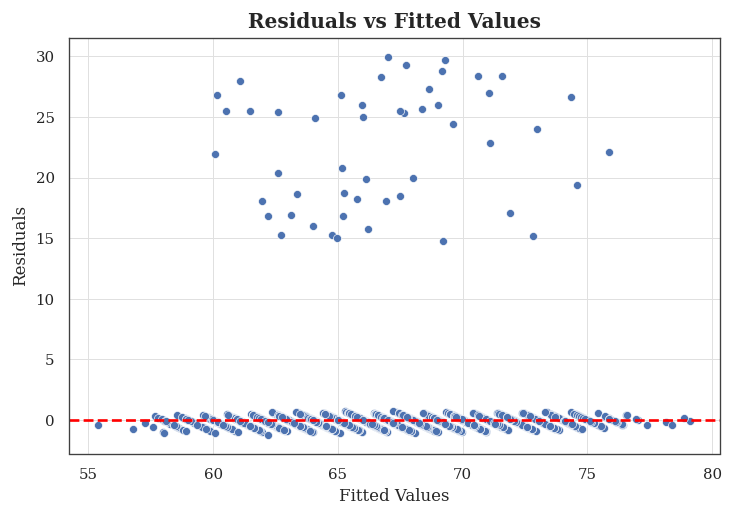

In [35]:
# residual vs fitted plot
residuals = model.resid
fitted = model.fittedvalues
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

Comment:

Most points are clustered near 0 residual, but there is a separate band of very large positive residuals.

There exist two possible reasons:

One is that we have outliers which can be not fitted well by linear model

The other is that the model is misspecified which may exlude some important patterns like interaction terms and ploynomial terms.

###  Influential observations

To assess the possibility the high positive residuals arising from outliers, I evaluate the presence of influential observations using leverage and Cook's distance

In [36]:
# Influence diagnostics: leverage and Cook's distance

influence = model.get_influence()

cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
studentized_resid = influence.resid_studentized_internal

n = int(model.nobs)
p = int(model.df_model + 1)  # number of fitted parameters, including intercept

cook_threshold = 4 / n
leverage_threshold = 2 * p / n

row_index = model.model.data.row_labels

influence_df = pd.DataFrame({
    "cook_distance": cooks_d,
    "leverage": leverage,
    "studentized_residual": studentized_resid,
    "residual": model.resid,
    "fitted": model.fittedvalues,
}, index=row_index)

influence_df["high_cook"] = influence_df["cook_distance"] > cook_threshold
influence_df["high_leverage"] = influence_df["leverage"] > leverage_threshold
influence_df["high_positive_residual"] = influence_df["studentized_residual"] > 2

influence_df["influential"] = (
    influence_df["high_cook"] |
    influence_df["high_leverage"]
)

print(f"Cook's distance threshold: {cook_threshold:.5f}")
print(f"Leverage threshold: {leverage_threshold:.5f}")
print(f"Number of influential observations: {influence_df['influential'].sum()}")

influence_df.sort_values("cook_distance", ascending=False).head(10)


Cook's distance threshold: 0.00063
Leverage threshold: 0.00878
Number of influential observations: 55


,cook_distance,leverage,studentized_residual,residual,fitted,high_cook,high_leverage,high_positive_residual,influential
1109,0.050384,0.008770,12.627175,26.016572,65.983428,True,False,True,True
1525,0.044482,0.007385,12.938314,26.676249,74.323751,True,False,True,True
2425,0.037341,0.005025,14.388281,29.701042,69.298958,True,False,True,True
4779,0.035560,0.005844,13.014973,26.855134,65.144866,True,False,True,True
217,0.034848,0.005300,13.532502,27.930639,61.069361,True,False,True,True
3141,0.034614,0.006308,12.355892,25.489227,60.510773,True,False,True,True
4531,0.033985,0.006258,12.292183,25.358438,67.641562,True,False,True,True
2904,0.030997,0.005699,12.305052,25.392124,62.607876,True,False,True,True
6393,0.030311,0.004335,13.961052,28.829120,69.170880,True,False,True,True
2595,0.029748,0.005413,12.370829,25.531529,61.468471,True,False,True,True


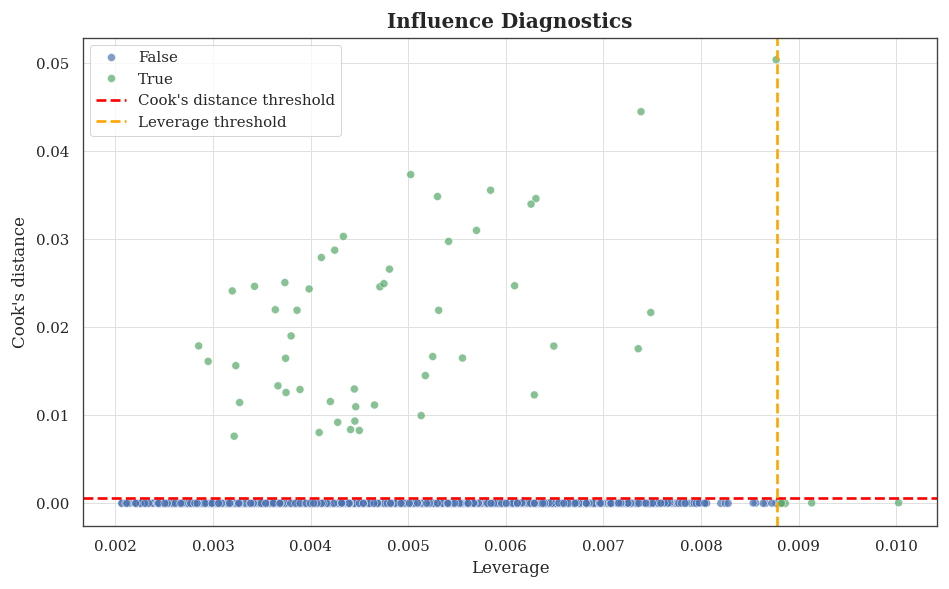

In [37]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=influence_df,
    x="leverage",
    y="cook_distance",
    hue="influential",
    alpha=0.7
)

plt.axhline(cook_threshold, color="red", linestyle="--", label="Cook's distance threshold")
plt.axvline(leverage_threshold, color="orange", linestyle="--", label="Leverage threshold")

plt.xlabel("Leverage")
plt.ylabel("Cook's distance")
plt.title("Influence Diagnostics")
plt.legend()
plt.tight_layout()
plt.savefig('../figs/ols_influence_diagnostics.png')
plt.show()


In [38]:
high_positive_resid = influence_df[
    influence_df["high_positive_residual"]
].sort_values("studentized_residual", ascending=False)

high_positive_resid.head(10)


,cook_distance,leverage,studentized_residual,residual,fitted,high_cook,high_leverage,high_positive_residual,influential
529,0.024123,0.003197,14.512177,29.984303,67.015697,True,False,True,True
2425,0.037341,0.005025,14.388281,29.701042,69.298958,True,False,True,True
919,0.024648,0.003425,14.170941,29.275911,67.724089,True,False,True,True
6393,0.030311,0.004335,13.961052,28.829120,69.170880,True,False,True,True
94,0.027921,0.004110,13.763521,28.424443,71.575557,True,False,True,True
3579,0.028752,0.004246,13.739720,28.373344,70.626656,True,False,True,True
4297,0.025077,0.003736,13.683917,28.265352,66.734648,True,False,True,True
217,0.034848,0.005300,13.532502,27.930639,61.069361,True,False,True,True
3457,0.017881,0.002853,13.229441,27.338702,68.661298,True,False,True,True
4192,0.024348,0.003984,13.054676,26.962235,71.037765,True,False,True,True


In [39]:
# ratio of different types of influential points
print("Proportion of influential points with high Cook's distance:", influence_df["high_cook"].mean())
print("Proportion of influential points with high leverage:", influence_df["high_leverage"].mean())
print("Proportion of influential points with high positive residuals:", influence_df["high_positive_residual"].mean())

Proportion of influential points with high Cook's distance: 0.00783944810285356
Proportion of influential points with high leverage: 0.0007839448102853559
Proportion of influential points with high positive residuals: 0.00783944810285356


In [40]:
# union of all influential points
influence_df["any_influential"] = (
    influence_df["high_cook"] |
    influence_df["high_leverage"] |
    influence_df["high_positive_residual"]
)
influence_df["any_influential"].mean()

np.float64(0.008623392913138916)

In [41]:
# top 20 high cook's distance
influence_df.sort_values("cook_distance", ascending=False).head(20)

,cook_distance,leverage,studentized_residual,residual,fitted,high_cook,high_leverage,high_positive_residual,influential,any_influential
1109,0.050384,0.008770,12.627175,26.016572,65.983428,True,False,True,True,True
1525,0.044482,0.007385,12.938314,26.676249,74.323751,True,False,True,True,True
2425,0.037341,0.005025,14.388281,29.701042,69.298958,True,False,True,True,True
4779,0.035560,0.005844,13.014973,26.855134,65.144866,True,False,True,True,True
217,0.034848,0.005300,13.532502,27.930639,61.069361,True,False,True,True,True
3141,0.034614,0.006308,12.355892,25.489227,60.510773,True,False,True,True,True
4531,0.033985,0.006258,12.292183,25.358438,67.641562,True,False,True,True,True
2904,0.030997,0.005699,12.305052,25.392124,62.607876,True,False,True,True,True
6393,0.030311,0.004335,13.961052,28.829120,69.170880,True,False,True,True,True
2595,0.029748,0.005413,12.370829,25.531529,61.468471,True,False,True,True,True


Comment:

Based on the influence diagnostics, the observations with the largest positive residuals also show relatively large Cook’s distance and/or leverage values. This suggests that the upper band in the residual plot is likely driven by a small number of influential outlying observations rather than by a systematic pattern affecting the full sample. Therefore, the large positive residuals should be interpreted with caution, since these observations may have a disproportionate effect on the fitted model.

In [42]:
# optional: refit model without influential points
influential_idx = influence_df[influence_df["influential"]].index

model_no_influential = sm.OLS.from_formula(
    formula,
    data=data.drop(index=influential_idx)
).fit()

# compare treatment effect estimates and confidence intervals
print("Original model:")
print(f"Treatment effect: {model.params[T_COL]:.3f}")
print(f"95% CI: [{model.conf_int().loc[T_COL, 0]:.3f}, {model.conf_int().loc[T_COL, 1]:.3f}]")

print("\nModel without influential points:")
print(f"Treatment effect: {model_no_influential.params[T_COL]:.3f}")
print(f"95% CI: [{model_no_influential.conf_int().loc[T_COL, 0]:.3f}, {model_no_influential.conf_int().loc[T_COL, 1]:.3f}]")

Original model:
Treatment effect: 0.562
95% CI: [0.458, 0.666]

Model without influential points:
Treatment effect: 0.506
95% CI: [0.490, 0.521]


In [43]:
# prepare for report

def extract_model_summary(model, t_col=T_COL):
    treat_coef = model.params[t_col]
    treat_se = model.bse[t_col]
    treat_pval = model.pvalues[t_col]
    treat_ci_low, treat_ci_high = model.conf_int().loc[t_col]

    r_squared = model.rsquared
    adj_r_squared = model.rsquared_adj
    n = model.nobs

    summary = {
        "Treatment Effect": treat_coef,
        "Std. Error": treat_se,
        "p-value": treat_pval,
        "95% CI Low": treat_ci_low,
        "95% CI High": treat_ci_high,
        "R-squared": r_squared,
        "Adj. R-squared": adj_r_squared,
        "N": n
    }
    return pd.DataFrame(summary, index=[0])

summary_non_influential_df = extract_model_summary(model_no_influential)
summary_non_influential_df
print(summary_non_influential_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{rrrrrrrr}
\toprule
Treatment Effect & Std. Error & p-value & 95% CI Low & 95% CI High & R-squared & Adj. R-squared & N \\
\midrule
0.506 & 0.008 & 0.000 & 0.490 & 0.521 & 0.991 & 0.991 & 6323.000 \\
\bottomrule
\end{tabular}



In [44]:
influence_df['influential'].value_counts(normalize=True)

influential
False    0.991377
True     0.008623
Name: proportion, dtype: float64

I retain the full dataset for the primary analysis because I am not sure whether the influential observations arise from data collection error and the proportion is as small as 0.86% of the full dataset. 

However, I conduct a sensitivity analysis excluding observations with high Cook’s distance or leverage to assess whether the estimated treatment effect is driven by these points.

After excluding these influential observations, the estimated effect of extracurricular activities remains positive, although its magnitude becomes slightly smaller. The 95% confidence interval also becomes narrower, suggesting a more precise estimate in the restricted sample. Overall, the direction of the result is robust, but the change in magnitude indicates that influential observations have some effect on the estimated scale of the treatment effect.

### Heteroskedasticity

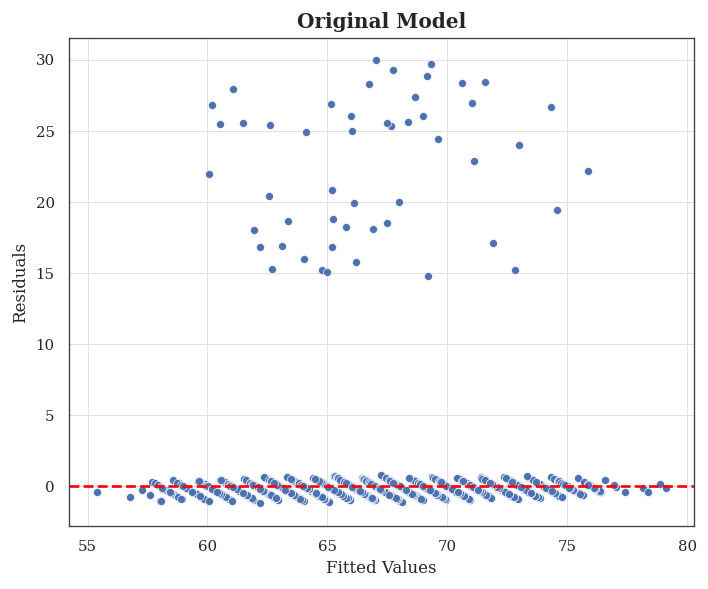

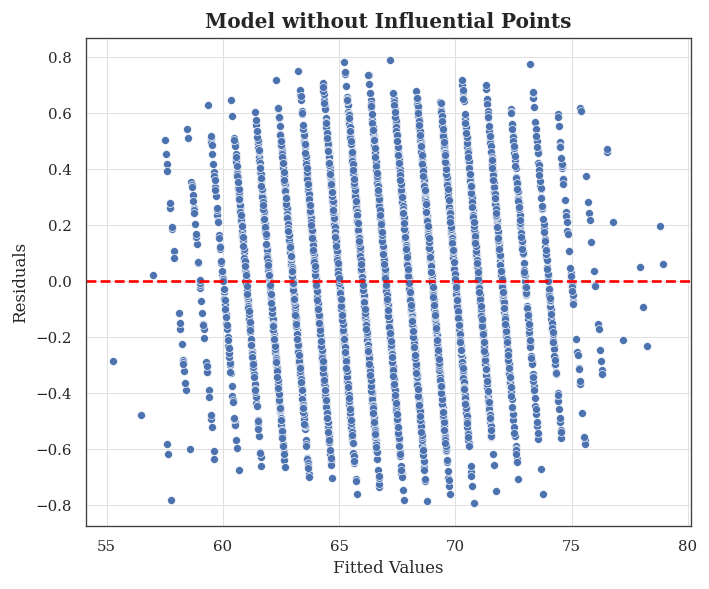

In [45]:
# plot residuals vs fitted values for model with/without influential points
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x=fitted, y=residuals, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Original Model")
plt.tight_layout()
plt.savefig('../figs/ols_residuals_fitted_original.png')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
residuals_no_influential = model_no_influential.resid
fitted_no_influential = model_no_influential.fittedvalues
sns.scatterplot(x=fitted_no_influential, y=residuals_no_influential, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Model without Influential Points")
plt.tight_layout()
plt.savefig('../figs/ols_residuals_fitted_no_influential.png')
plt.show()

Comment:

After removing influtentials, we can observe the residuals are now centered around 0 and spread looks more symmetric. Also, we can not detect obvious extreme cluster anymore.

While minor variation in spread remains, the homoskedasticity assumption appears more plausible under the cleaned sample.


In [46]:
# Breusch-Pagan test for formal heteroskedasticity test
bp_test = sm.stats.diagnostic.het_breuschpagan(model.resid, model.model.exog)
bp_statistic, bp_pvalue, _, _ = bp_test
print(f"Breusch-Pagan test statistic: {bp_statistic:.3f}")
print(f"Breusch-Pagan p-value: {bp_pvalue:.3f}")

Breusch-Pagan test statistic: 18.027
Breusch-Pagan p-value: 0.903


In [47]:
# bp test for model without influential points
bp_test_no_influential = sm.stats.diagnostic.het_breuschpagan(model_no_influential.resid, model_no_influential.model.exog)
bp_statistic_no_influential, bp_pvalue_no_influential, _, _ = bp_test_no_influential
print(f"Breusch-Pagan test statistic (no influential): {bp_statistic_no_influential:.3f}")
print(f"Breusch-Pagan p-value (no influential): {bp_pvalue_no_influential:.3f}")

Breusch-Pagan test statistic (no influential): 28.706
Breusch-Pagan p-value (no influential): 0.375


For the original model, the test yields a p-value of 0.903, and for the model excluding influential observations, the p-value is 0.375. In both cases, we fail to reject the null hypothesis of constant variance.

Although the p-value decreases after removing influential observations, it remains well above conventional significance levels, suggesting that the homoskedasticity assumption is plausible in both specifications. The reduction in p-value indicates that the test becomes more sensitive after removing extreme observations, but there is still no evidence of systematic heteroskedasticity.

### Multicollinearity

I use VIF to carry out formal analysis


In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = model.model.exog
vif_data = pd.DataFrame()
vif_data["feature"] = model.model.exog_names
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif_data = vif_data[vif_data["feature"] != "Intercept"]  # exclude intercept
vif_data.sort_values("VIF", ascending=False)

,feature,VIF
19,C(Distance_from_Home)[T.Near],2.826054
18,C(Distance_from_Home)[T.Moderate],2.825756
9,C(Family_Income)[T.Medium],1.853356
8,C(Family_Income)[T.Low],1.850859
13,C(Peer_Influence)[T.Neutral],1.759571
14,C(Peer_Influence)[T.Positive],1.756123
5,C(Motivation_Level)[T.Low],1.747266
6,C(Motivation_Level)[T.Medium],1.746924
1,C(Parental_Involvement)[T.Low],1.365790
2,C(Parental_Involvement)[T.Medium],1.362893


Comment:


Variance inflation factors (VIF) are used to assess multicollinearity among covariates. Excluding the intercept, all variables have VIF values below 3, indicating no significant multicollinearity.

## Conclusion


Based on the outcome regression model, participation in extracurricular activities is associated with higher exam performance after controlling for observed student, family, school, and behavioral covariates. The estimated coefficient for Extracurricular_Activities is positive, suggesting that students who participate in extracurricular activities score higher on average than comparable students who do not participate.

In the full OLS model, the estimated effect is approximately 0.56 points, with a 95% confidence interval of about [0.46, 0.67]. Since the confidence interval does not include zero, the result provides evidence of a positive association between extracurricular participation and exam score.

I also checked model diagnostics, including residual patterns and influential observations. Some large positive residuals appear to be related to a small number of influential observations, but a sensitivity analysis excluding these observations still produces a positive estimated effect. This suggests that the main conclusion is robust in direction, although the exact magnitude of the effect may be somewhat affected by these influential points.

Overall, the outcome regression analysis supports the conclusion that extracurricular activity participation has a positive estimated effect on exam performance, conditional on the observed covariates included in the model. However, because the data are observational, this conclusion depends on the assumption that the model adequately adjusts for confounding from the measured variables.

# Treatment effect heterogeneity

To examine whether the effect of extra-curricular activities varies across different subgroups of students, we will also explore treatment effect heterogeneity. This can be done by including interaction terms between the treatment variable and key covariates in the regression model:

\begin{equation*}
Y_i = \alpha_0 + \alpha_1 T_i + X_i^T \alpha + (T_i \cdot X_i)^T \gamma + \epsilon_i
\end{equation*}

## Interaction term selection

To select a potential interaction covaraites, I first plot outcome by subgroups and then check mean differences in subgroups

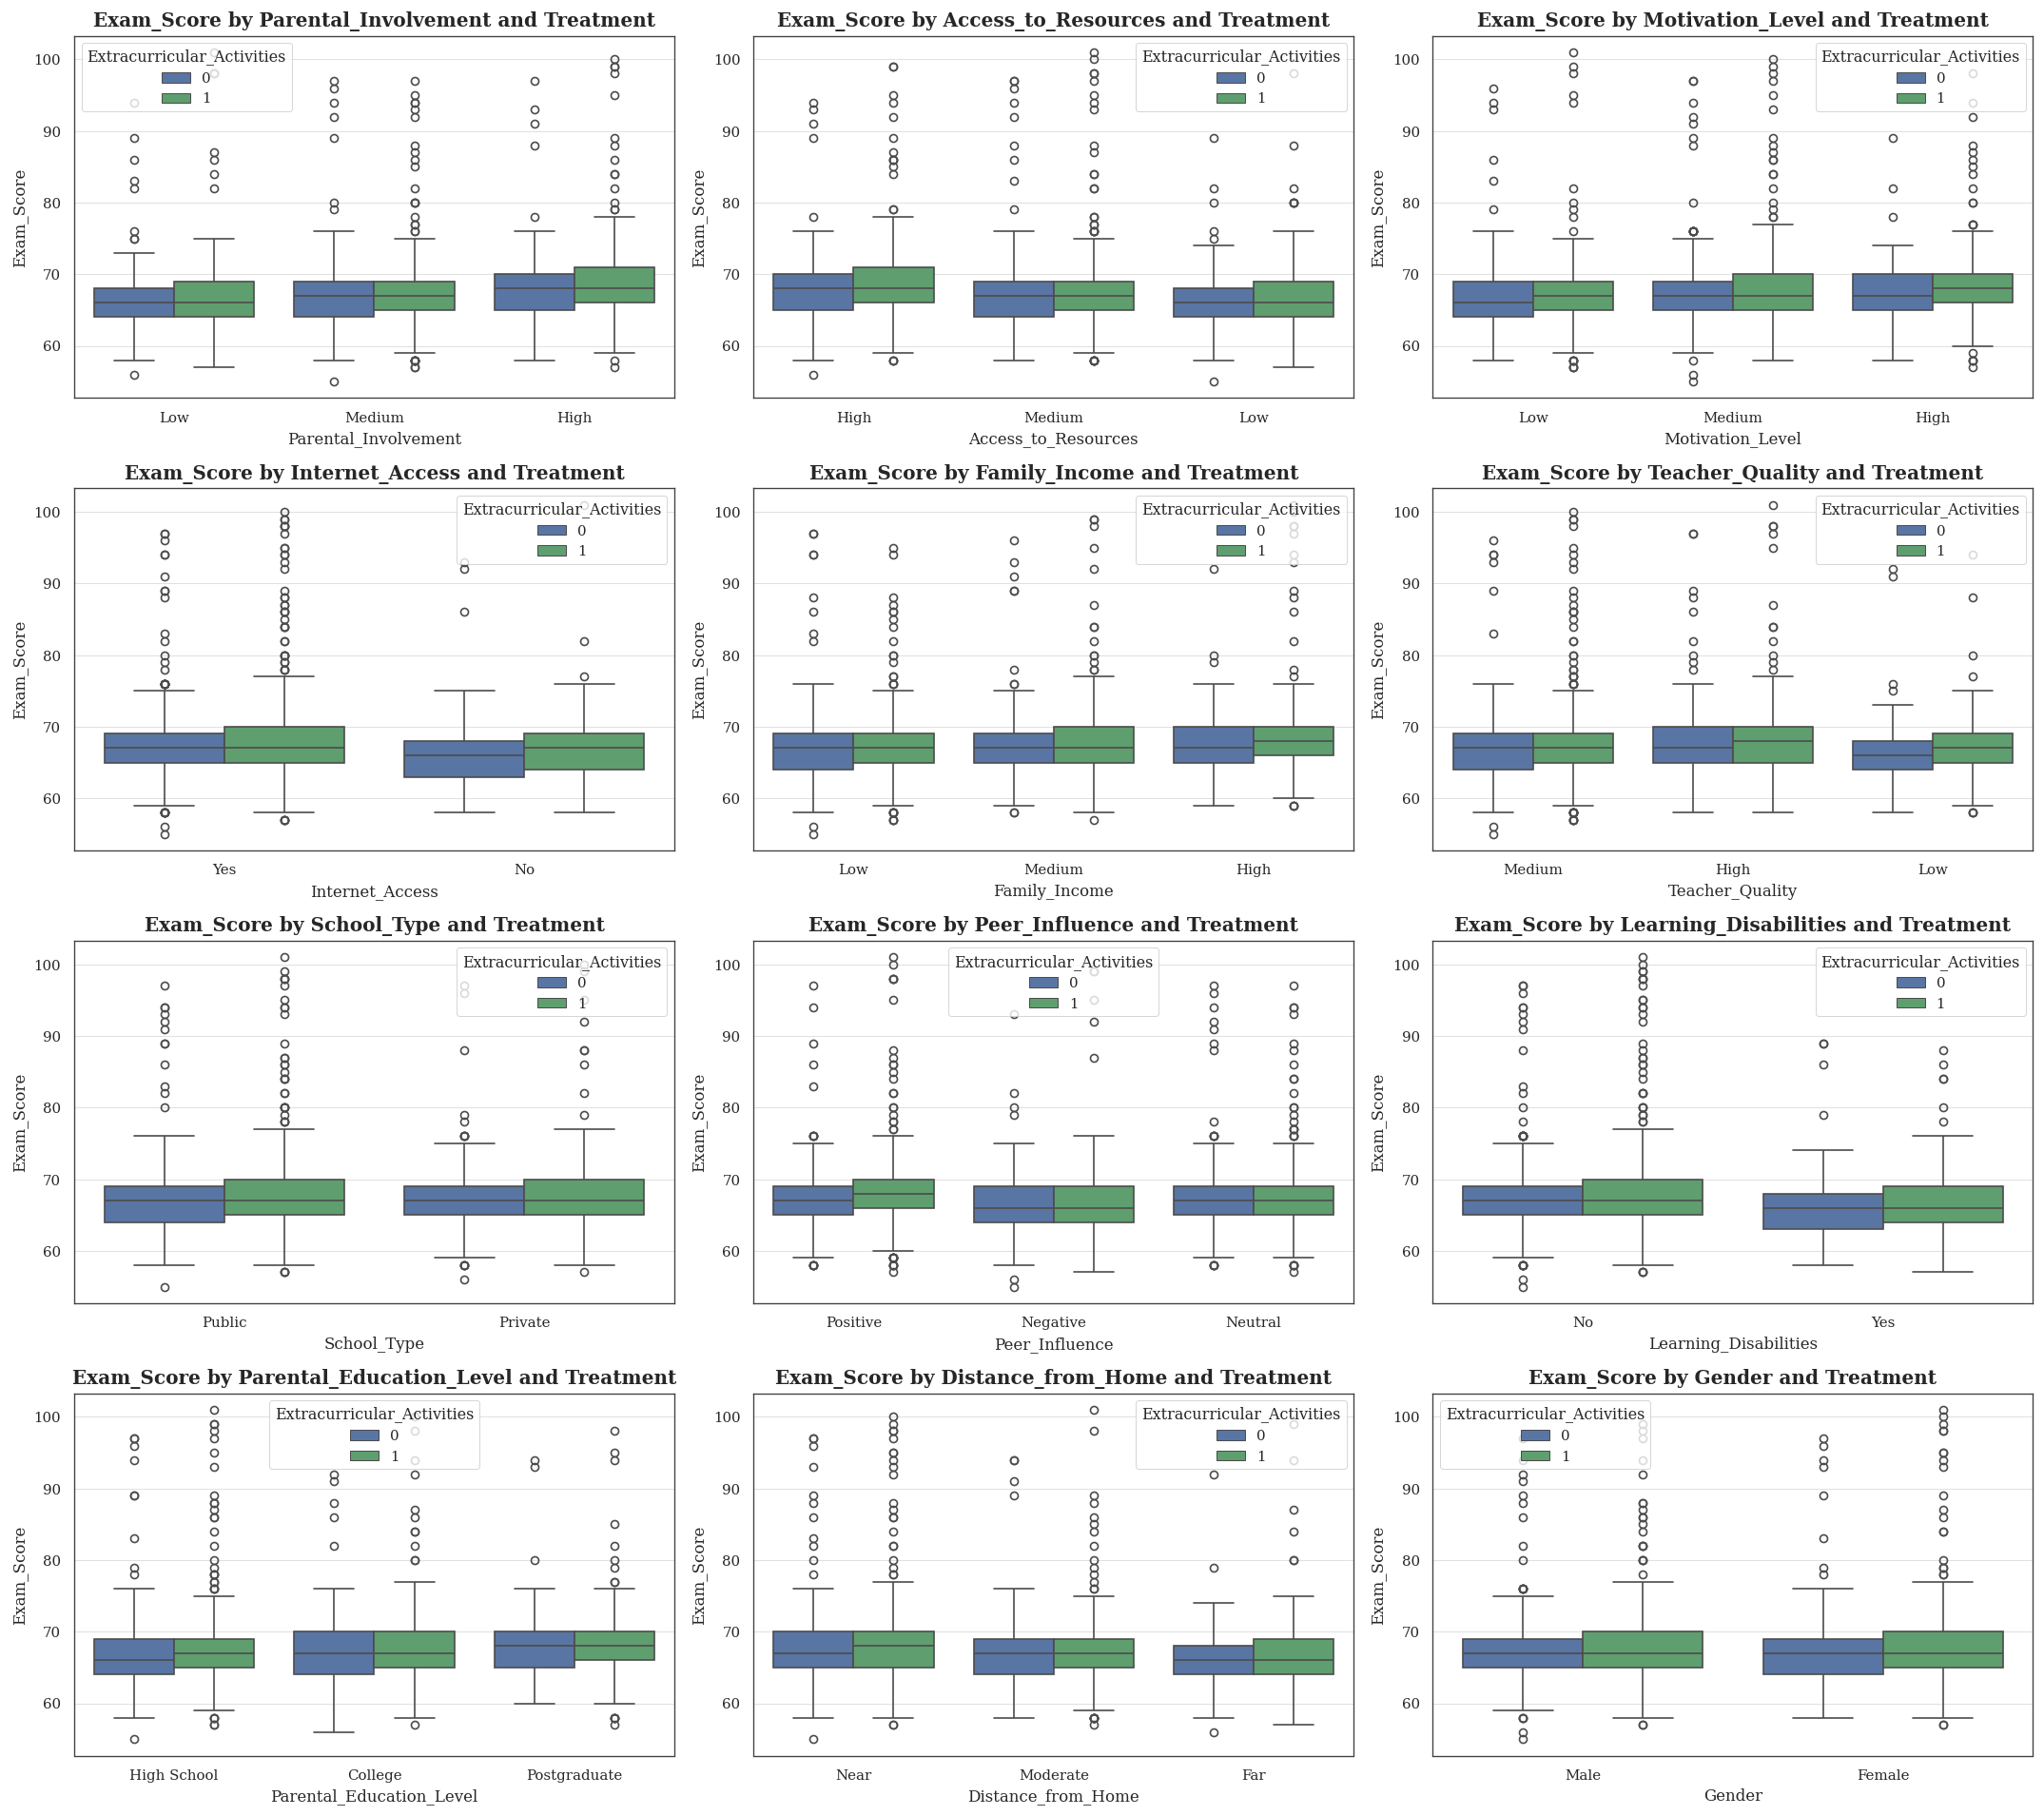

In [49]:
# catergorical variables x treatment interactions 
n_cols = 3
n_rows = int(np.ceil(len(CAT_CONVARS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(CAT_CONVARS):
    sns.boxplot(x = col, y = Y_COL, hue = T_COL, data=data, ax=axes[i])
    axes[i].set_title(f"{Y_COL} by {col} and Treatment")

# hide unused subplots
for j in range(len(CAT_CONVARS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../figs/cat_interactions.png')
plt.show()

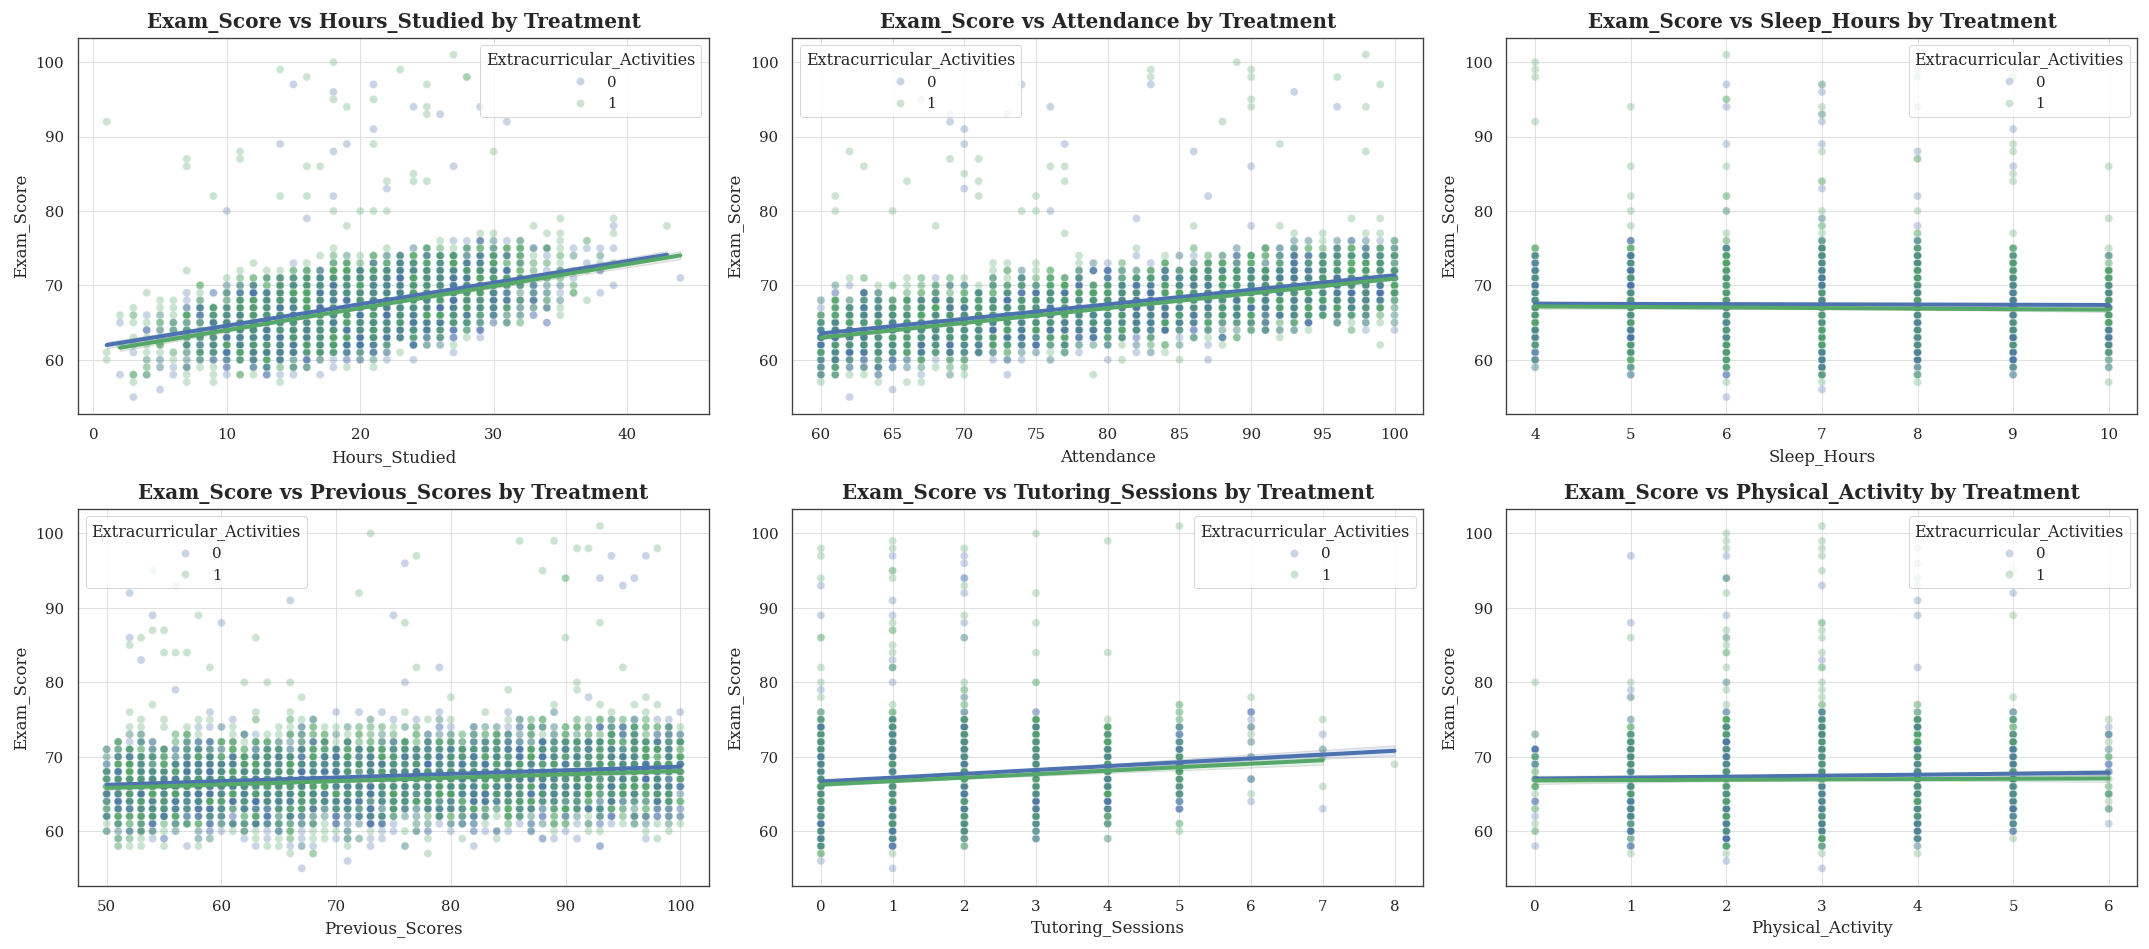

In [50]:
# continuous variables x treatment interactions

n_cols = 3
n_rows = int(np.ceil(len(NUM_CONVARS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(NUM_CONVARS):
    sns.scatterplot(
        x=col, y=Y_COL,
        hue=T_COL,
        data=data,
        alpha=0.3,
        ax=axes[i]
    )
    
    # add regression lines
    sns.regplot(
        x=col, y=Y_COL,
        data=data[data[T_COL]==1],
        scatter=False, ax=axes[i],
        label="T=1"
    )
    sns.regplot(
        x=col, y=Y_COL,
        data=data[data[T_COL]==0],
        scatter=False, ax=axes[i],
        label="T=0"
    )

    axes[i].set_title(f"{Y_COL} vs {col} by Treatment")

# hide unused
for j in range(len(NUM_CONVARS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../figs/num_interactions.png')
plt.show()

Based on the subgroup plots, I identify several candidate interaction terms:

+ **Hours_studied x Treatment**: both groups increase with hours, but slope are slightly different
+ **Motivation_level x Treatment**: we see gap increases across levels

## Regression with interaction

In [51]:
interactions = [
    "Motivation_Level",
    "Hours_Studied"
    ]

interaction_formula = make_formula(interactions=interactions)
print(interaction_formula)

Exam_Score ~ Extracurricular_Activities + Hours_Studied + Attendance + Sleep_Hours + Previous_Scores + Tutoring_Sessions + Physical_Activity + C(Parental_Involvement) + C(Access_to_Resources) + C(Motivation_Level) + C(Internet_Access) + C(Family_Income) + C(Teacher_Quality) + C(School_Type) + C(Peer_Influence) + C(Learning_Disabilities) + C(Parental_Education_Level) + C(Distance_from_Home) + C(Gender) + Extracurricular_Activities:C(Motivation_Level) + Extracurricular_Activities:Hours_Studied


In [52]:
model_with_interactions = sm.OLS.from_formula(interaction_formula, data=data).fit()
print(model_with_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     549.0
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        12:06:58   Log-Likelihood:                -13673.
No. Observations:                6378   AIC:                         2.741e+04
Df Residuals:                    6347   BIC:                         2.762e+04
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

The model output is :

\begin{align*}
Y = 0.9208 \times T -0.2498 (T \times \text{Low Motivation Level}) -0.1899 (T \times \text{Medium Motivation Level}) -0.0094 (T \times \text{Hours\_Studied} ) + \dots
\end{align*}

Interpretation
---
**Baseline treatment effect**:

The coefficient on **extracurricular_activities** is 

$$
\hat{\beta}_T = 0.9208 \quad (\text{SE} = 0.212,\; p < 0.001)
$$

This reprsents the treatment effect for the reference group, which consists of students with high motivation level and 0 study hours

Thus, for highly motivated students, participation in extracurricular activites is associated with an increase of approximately 0.92 points in exam scores, holiding other variables constant.

**Interaction with motivation level**:

The estimated interaction terms are:

$$
\begin{aligned}
T \times \text{Low Motivation}: & \quad -0.2498 \quad (p = 0.104) \\
T \times \text{Medium Motivation}: & \quad -0.1899 \quad (p = 0.175)
\end{aligned}
$$

These coefficients imply that the treatment effect varies by motivation level:

* High motivation (reference group):
    9208
* Medium motivation:
    9208 - 0.1899 = 0.7309
* Low motivation:
    9208 - 0.2498 = 0.6710


The results suggest that students with higher motivation benefit more from taking part in extracurricular activities. However, both interaction terms are not statistically significant at the 5\% level, indicating that there is no strong evidence that the treatment effect differs by motivation level.


**Interaction with study hours**:

The interaction between extracurricular participation and study hours is:
$$
T \times \text{Hours\_Studied} = -0.0094 \quad (p = 0.287)
$$
This implies that the treatment effect varies with study hours as:

$$
\text{Effect of } T = 0.9208 - 0.0094 \times \text{Hours\_Studied}
$$

This suggests that the benefit of extracurricular activities declines as study hours increase. Each additional hour studied reduces the treatment effect by approximately 0.0094 points. The reality explanation can be a substitution effect where extracurricular activities may crow out study time for students who already devote substantial effor to studying. Still, the interaction term is not statistically significant ($p = 0.287$), indicating the heterogeneous treatment effect is not strongly supported by data.



## Diagnostics

### Heteroskedasticity

In [53]:
bp_test_interactions = sm.stats.diagnostic.het_breuschpagan(model_with_interactions.resid, model_with_interactions.model.exog)
bp_statistic_interactions, bp_pvalue_interactions, _, _ = bp_test_interactions
print(f"Breusch-Pagan test statistic (with interactions): {bp_statistic_interactions:.3f}")
print(f"Breusch-Pagan p-value (with interactions): {bp_pvalue_interactions:.3f}")

Breusch-Pagan test statistic (with interactions): 21.541
Breusch-Pagan p-value (with interactions): 0.870


We fail to reject the null hypothesis, which means we can not identify the heteroskedasticity.

### Multicollinearity

In [54]:
X = model_with_interactions.model.exog
vif_data_interactions = pd.DataFrame()
vif_data_interactions["feature"] = model_with_interactions.model.exog_names
vif_data_interactions["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif_data_interactions = vif_data_interactions[vif_data_interactions["feature"] != "Intercept"]  # exclude intercept
vif_data_interactions.sort_values("VIF", ascending=False)

,feature,VIF
21,Extracurricular_Activities,16.117265
30,Extracurricular_Activities:Hours_Studied,13.741487
23,Extracurricular_Activities:C(Motivation_Level)...,6.180215
22,Extracurricular_Activities:C(Motivation_Level)...,5.009062
6,C(Motivation_Level)[T.Medium],4.434490
5,C(Motivation_Level)[T.Low],4.374679
19,C(Distance_from_Home)[T.Near],2.828069
18,C(Distance_from_Home)[T.Moderate],2.827676
24,Hours_Studied,2.539532
9,C(Family_Income)[T.Medium],1.854012


We see high VIF in the interaction terms but for other covaraites, the VIF is below 5 which suggests the mulicollinearity is small or moderate.

### Influential

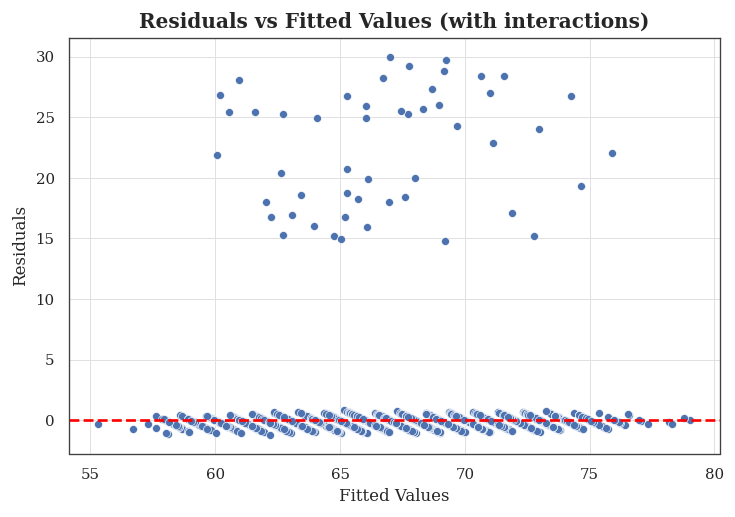

In [55]:
# resdiuals vs fitted for model with interactions
residuals_interactions = model_with_interactions.resid
fitted_interactions = model_with_interactions.fittedvalues
sns.scatterplot(x=fitted_interactions, y=residuals_interactions)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (with interactions)")
plt.show()

we still see the high positive residual patterns. We can do sensitivity analysis: remove the influential observations identified before, and compare the effect change we care about.

In [56]:
# model with interactions without influential points
model_with_interactions_no_influential = sm.OLS.from_formula(
    interaction_formula,
    data=data.drop(index=influential_idx)
).fit()

# compare treatment effect and interaction term estimates and confidence intervals

cols_to_compare = [
    col for col in model_with_interactions.model.exog_names
    if T_COL in col
]

rows = []
for col in cols_to_compare:
    rows.append({
        "term": col,
        'model': "with interactions",
        "coef": model_with_interactions.params[col],
        "ci_low": model_with_interactions.conf_int().loc[col, 0],
        "ci_high": model_with_interactions.conf_int().loc[col, 1],
        "pvalue": model_with_interactions.pvalues[col].round(3),
    })
    rows.append({
        "term": col,
        'model': "without influential",
        "coef": model_with_interactions_no_influential.params[col],
        "ci_low": model_with_interactions_no_influential.conf_int().loc[col, 0],
        "ci_high": model_with_interactions_no_influential.conf_int().loc[col, 1],
        "pvalue": model_with_interactions_no_influential.pvalues[col].round(3),
    })

comparison_df = pd.DataFrame(rows).set_index(["term", "model"])
comparison_df


coef  \
term                                               model                           
Extracurricular_Activities                         with interactions    0.920799   
                                                   without influential  0.489113   
Extracurricular_Activities:C(Motivation_Level)[... with interactions   -0.249771   
                                                   without influential -0.039525   
Extracurricular_Activities:C(Motivation_Level)[... with interactions   -0.189899   
                                                   without influential -0.003841   
Extracurricular_Activities:Hours_Studied           with interactions   -0.009443   
                                                   without influential  0.001501   

                                                                          ci_low  \
term                                               model                           
Extracurricular_Activities                         with interactions    0.505080   
                                                   without influential  0.425345   
Extracurricular_Activities:C(Motivation_Level)[... with interactions   -0.551229   
                                                   without influential -0.085736   
Extracurricular_Activities:C(Motivation_Level)[... with interactions   -0.464655   
                                                   without influential -0.045968   
Extracurricular_Activities:Hours_Studied           with interactions   -0.026828   
                                                   without influential -0.001165   

                                                                         ci_high  \
term                                               model                           
Extracurricular_Activities                         with interactions    1.336518   
                                                   without influential  0.552882   
Extracurricular_Activities:C(Motivation_Level)[... with interactions    0.051688   
                                                   without influential  0.006686   
Extracurricular_Activities:C(Motivation_Level)[... with interactions    0.084857   
                                                   without influential  0.038285   
Extracurricular_Activities:Hours_Studied           with interactions    0.007942   
                                                   without influential  0.004167   

                                                                        pvalue  
term                                               model                        
Extracurricular_Activities                         with interactions     0.000  
                                                   without influential   0.000  
Extracurricular_Activities:C(Motivation_Level)[... with interactions     0.104  
                                                   without influential   0.094  
Extracurricular_Activities:C(Motivation_Level)[... with interactions     0.175  
                                                   without influential   0.858  
Extracurricular_Activities:Hours_Studied           with interactions     0.287  
                                                   without influential   0.270

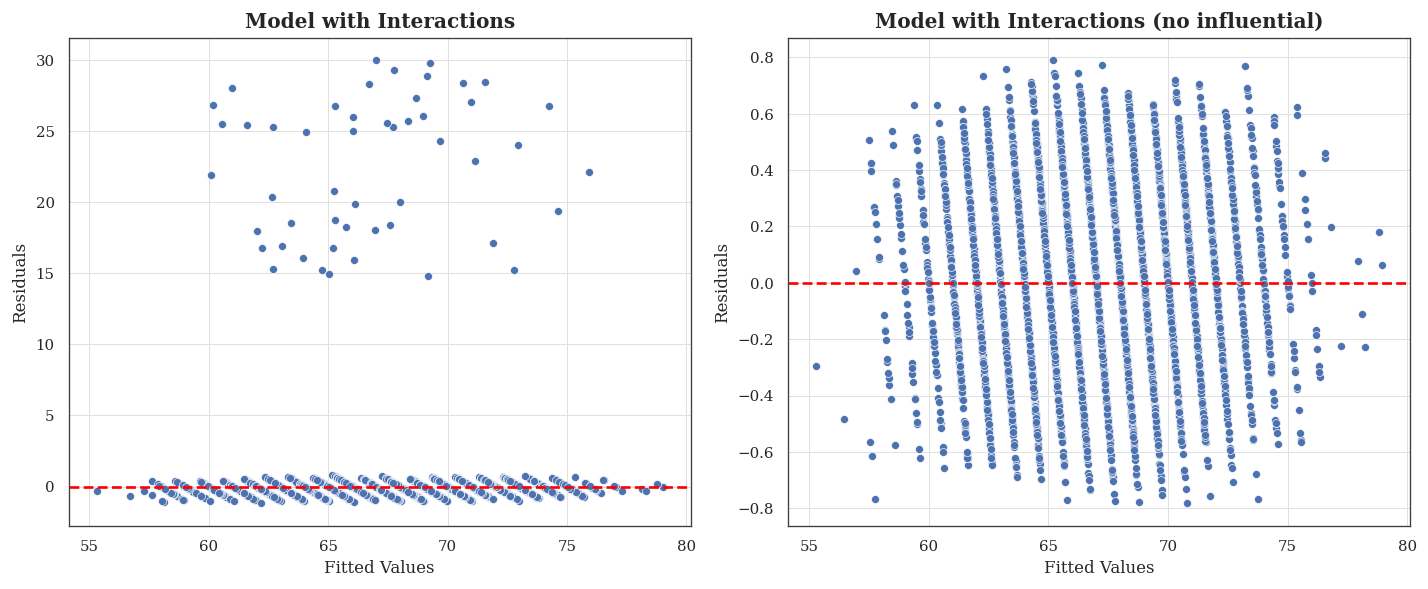

In [57]:
# fitted vs residuals plot (influential vs non-influential)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=fitted_interactions, y=residuals_interactions, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Model with Interactions")    

residuals_interactions_no_influential = model_with_interactions_no_influential.resid
fitted_interactions_no_influential = model_with_interactions_no_influential.fittedvalues
sns.scatterplot(x=fitted_interactions_no_influential, y=residuals_interactions_no_influential, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Model with Interactions (no influential)")
plt.tight_layout()
plt.show()

The sensitivity analysis reveals that the estimated interaction effects are not robust to the removal of influential observations. In particular, the interaction terms involving motivation level substantially decrease in magnitude and lose any suggestive pattern, while the interaction with study hours remains small and statistically insignificant in both specifications.

In contrast, the main treatment effect remains positive and statistically significant, although its magnitude decreases after removing influential observations.

These findings indicate that while there may be weak evidence of heterogeneous effects in the full sample, such patterns are not stable and should be interpreted with caution. Overall, the results suggest that the impact of extracurricular activities is relatively homogeneous across student characteristics in this dataset.

# Propensity score methods

The above analysis relies on a key assumption that conditional on the observed covariates $X_i$, the treatment assignment $T_i$ is independent of the potential outcomes:

\begin{equation*}
Y_i(1), Y_i(0) \perp T_i \mid X_i
\end{equation*}

In the real-world observational studies, that is not always the cases. So we need propensity score to make sure the treatment and control group is comparable.

In [58]:
# fit propensity score model
ps_formula = make_ps_formula()
ps_model = sm.Logit.from_formula(ps_formula, data=data).fit()
print(ps_model.summary())

Optimization terminated successfully.
         Current function value: 0.672113
         Iterations 4
                               Logit Regression Results                               
Dep. Variable:     Extracurricular_Activities   No. Observations:                 6378
Model:                                  Logit   Df Residuals:                     6351
Method:                                   MLE   Df Model:                           26
Date:                        Tue, 12 May 2026   Pseudo R-squ.:                0.003170
Time:                                12:07:00   Log-Likelihood:                -4286.7
converged:                               True   LL-Null:                       -4300.4
Covariance Type:                    nonrobust   LLR p-value:                    0.3958
                                                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

The logit result show:

+ Pseudo $R^2$ is around 0.003 (very low)
+ Most covariates not significant

This actually implies treatment assignment(extra-curricular activities) is close to **random**. Thus, we have an expectation that OLS is already reliable and IPW should be similar.

In [59]:
data_ps = data.copy()
data_ps["propensity_score"] = ps_model.predict()

## check overlap

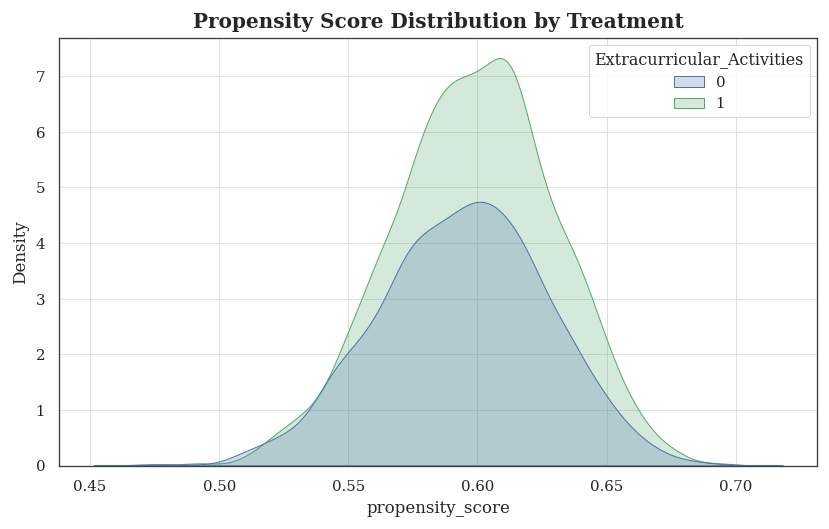

In [60]:
sns.kdeplot(data=data_ps, x="propensity_score", hue=T_COL, fill=True)
plt.title("Propensity Score Distribution by Treatment")
plt.tight_layout()
plt.savefig('../figs/ps_distribution.png')
plt.show()

Comment: 

the propensity score distributions share a large overlap between treated and control.

## Check balance

In [61]:
data_ps['weight'] = np.where(
    data_ps[T_COL] == 1,
    1 / data_ps["propensity_score"],
    1 / (1 - data_ps["propensity_score"])
)

# Calculate standardized mean differences (SMD) for balance checking
def calculate_smd(data, treatment_col, var, weight_col=None):
    """Calculate standardized mean difference"""
    treated = data[data[treatment_col] == 1][var]
    control = data[data[treatment_col] == 0][var]
    
    if weight_col:
        treated_w = data[data[treatment_col] == 1][weight_col]
        control_w = data[data[treatment_col] == 0][weight_col]
        
        treated_mean = np.average(treated, weights=treated_w)
        control_mean = np.average(control, weights=control_w)
        treated_var = np.average((treated - treated_mean)**2, weights=treated_w)
        control_var = np.average((control - control_mean)**2, weights=control_w)
    else:
        treated_mean = treated.mean()
        control_mean = control.mean()
        treated_var = treated.var()
        control_var = control.var()
    
    pooled_std = np.sqrt((treated_var + control_var) / 2)
    smd = (treated_mean - control_mean) / pooled_std if pooled_std > 0 else 0
    
    return smd

# Calculate SMD for all covariates
balance_rows = []

# categorical variables
for col in CAT_CONVARS:
    # one-hot encode for SMD calculation
    dummies = pd.get_dummies(data_ps[col], prefix=col)
    for dummy_col in dummies.columns:
        data_ps[dummy_col] = dummies[dummy_col]
        smd_unweighted = calculate_smd(data_ps, T_COL, dummy_col)
        smd_weighted = calculate_smd(data_ps, T_COL, dummy_col, weight_col='weight')
        balance_rows.append({
            "variable": dummy_col,
            "smd_unweighted": smd_unweighted,
            "smd_weighted": smd_weighted,
            'abs_smd_unweighted': abs(smd_unweighted),
            'abs_smd_weighted': abs(smd_weighted)
        })
# continuous variables
for col in NUM_CONVARS:
    smd_unweighted = calculate_smd(data_ps, T_COL, col)
    smd_weighted = calculate_smd(data_ps, T_COL, col, weight_col='weight')
    balance_rows.append({
        "variable": col,
        "smd_unweighted": smd_unweighted,
        "smd_weighted": smd_weighted,
        'abs_smd_unweighted': abs(smd_unweighted),
        'abs_smd_weighted': abs(smd_weighted)
    })
balance_df = pd.DataFrame(balance_rows)
balance_df.sort_values("smd_unweighted", ascending=False).head(10)

,variable,smd_unweighted,smd_weighted,abs_smd_unweighted,abs_smd_weighted
28,Distance_from_Home_Moderate,0.057402,-0.001114,0.057402,0.001114
21,Peer_Influence_Positive,0.045432,-0.000407,0.045432,0.000407
4,Access_to_Resources_Low,0.038500,0.000566,0.038500,0.000566
24,Parental_Education_Level_College,0.034927,-0.000570,0.034927,0.000570
2,Parental_Involvement_Medium,0.029316,0.000111,0.029316,0.000111
6,Motivation_Level_High,0.027352,0.000671,0.027352,0.000671
22,Learning_Disabilities_No,0.022759,-0.000772,0.022759,0.000772
1,Parental_Involvement_Low,0.021776,-0.000846,0.021776,0.000846
19,Peer_Influence_Negative,0.021087,0.000566,0.021087,0.000566
13,Family_Income_Medium,0.017765,-0.001076,0.017765,0.001076


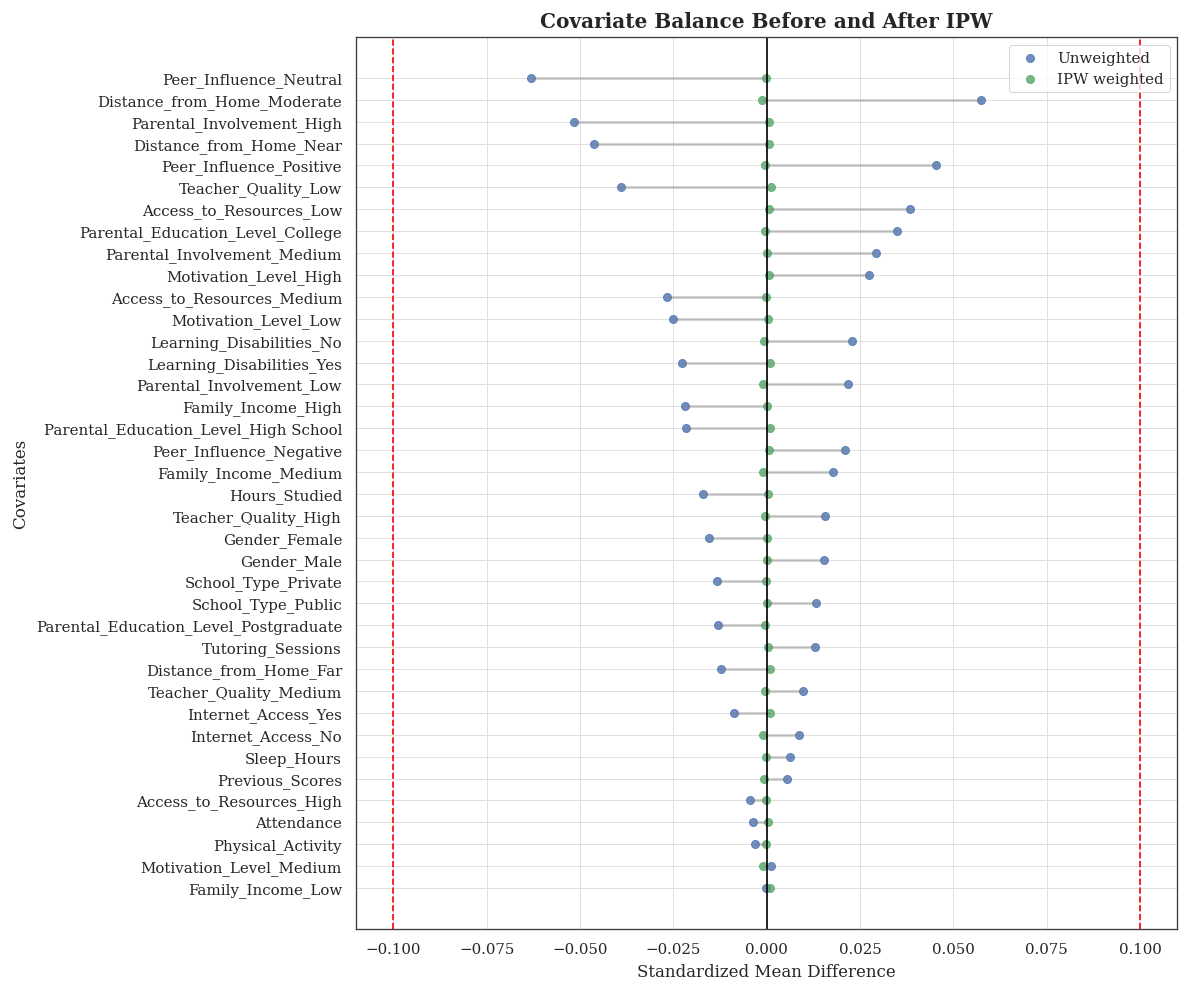

In [62]:
plot_df = balance_df.sort_values("abs_smd_unweighted", ascending=True)

plt.figure(figsize=(10, max(6, 0.22 * len(plot_df))))
plt.hlines(y=plot_df["variable"], xmin=plot_df["smd_unweighted"], xmax=plot_df["smd_weighted"], color="gray", alpha=0.4)
plt.scatter(plot_df["smd_unweighted"], plot_df["variable"], label="Unweighted", alpha=0.8)
plt.scatter(plot_df["smd_weighted"], plot_df["variable"], label="IPW weighted", alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.axvline(0.1, color="red", linestyle="--", linewidth=1)
plt.axvline(-0.1, color="red", linestyle="--", linewidth=1)
plt.xlabel("Standardized Mean Difference")
plt.ylabel("Covariates")
plt.title("Covariate Balance Before and After IPW")
plt.legend()
plt.tight_layout()
plt.savefig('../figs/balance_ipw.png')
plt.show()

Comment:

Based on the previous logit model, we have already known the treatment assignment is near random. However, with the inverse probability weight, we can see the standarized mean differences become even smaller for all the covariates with all the values are within [-0.01,0.01]. It gives us a more balanced dataset given all the observational features.

## IPW + WLS

In [63]:
model_wls = sm.WLS.from_formula(formula, data=data_ps, weights=data_ps['weight']).fit()
print(model_wls.summary())

                            WLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.728
Model:                            WLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     628.1
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        12:07:01   Log-Likelihood:                -13651.
No. Observations:                6378   AIC:                         2.736e+04
Df Residuals:                    6350   BIC:                         2.755e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

To estimate the causal effect of extracurricular participation, I apply inverse probability weighting (IPW) using propensity scores and estimate the treatment effect via weighted least squares (WLS). 

The estimated coefficient on extracurricular participation is 0.562 (95% CI: [0.462, 0.662], p < 0.001), indicating a positive and statistically significant effect on exam scores. The result is very close to the original model. It supports the robustness of our conclusion in the baseline orignial OLS model.

In [64]:
# compare treatment effect estimates and confidence intervals: baseline OLS vs IPW weighted

print("Baseline OLS model:")
print(f"Treatment effect: {model.params[T_COL]:.3f}")
print(f"95% CI: [{model.conf_int().loc[T_COL, 0]:.3f}, {model.conf_int().loc[T_COL, 1]:.3f}]")


print("\nIPW Weighted model:")
print(f"Treatment effect: {model_wls.params[T_COL]:.3f}")
print(f"95% CI: [{model_wls.conf_int().loc[T_COL, 0]:.3f}, {model_wls.conf_int().loc[T_COL, 1]:.3f}]")

Baseline OLS model:
Treatment effect: 0.562
95% CI: [0.458, 0.666]

IPW Weighted model:
Treatment effect: 0.562
95% CI: [0.462, 0.662]


In [65]:
# extract model summaries for report
summary_ipw_df = extract_model_summary(model_wls)
summary_ipw_df

,Treatment Effect,Std. Error,p-value,95% CI Low,95% CI High,R-squared,Adj. R-squared,N
0,0.562057,0.051096,6.810361e-28,0.461892,0.662222,0.727557,0.726398,6378.0


## Diagnostic

Since the result does not change a lot compared with base model due to the near randomness of treatment assignment, I will mainly check the influentials for WLS model.

### Influentials

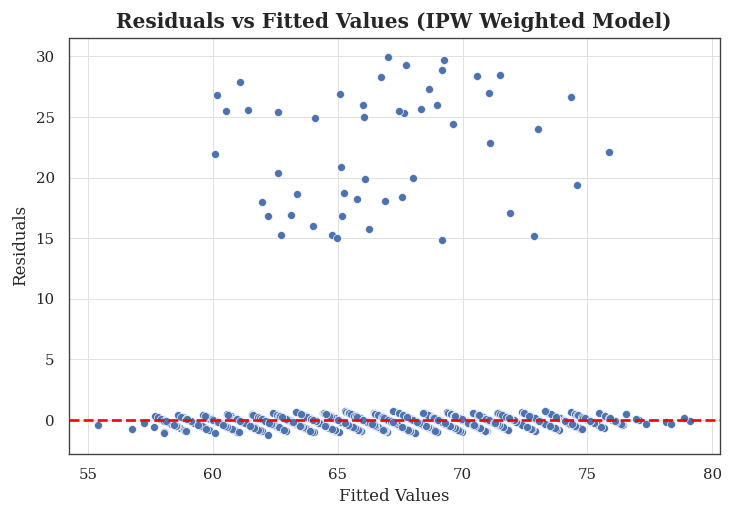

In [66]:
# fitted vs residuals plot for IPW weighted model
residuals_wls = model_wls.resid
fitted_wls = model_wls.fittedvalues
sns.scatterplot(x=fitted_wls, y=residuals_wls)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (IPW Weighted Model)")
plt.show()

In [67]:
# wls without influential points
model_wls_no_influential = sm.WLS.from_formula(
    formula,
    data=data_ps.drop(index=influential_idx),
    weights=data_ps.drop(index=influential_idx)['weight']
).fit()

# compare treatment effect estimates and confidence intervals
print("IPW Weighted model without influential points:")
print(f"Treatment effect: {model_wls_no_influential.params[T_COL]:.3f}")
print(f"95% CI: [{model_wls_no_influential.conf_int().loc[T_COL, 0]:.3f}, {model_wls_no_influential.conf_int().loc[T_COL, 1]:.3f}]")
print("IPW Weighted model with influential points:")
print(f"Treatment effect: {model_wls.params[T_COL]:.3f}")
print(f"95% CI: [{model_wls.conf_int().loc[T_COL, 0]:.3f}, {model_wls.conf_int().loc[T_COL, 1]:.3f}]")


IPW Weighted model without influential points:
Treatment effect: 0.505
95% CI: [0.490, 0.521]
IPW Weighted model with influential points:
Treatment effect: 0.562
95% CI: [0.462, 0.662]


In [68]:
# extract model summaries for report
summary_ipw_no_influential_df = extract_model_summary(model_wls_no_influential)
summary_ipw_no_influential_df


,Treatment Effect,Std. Error,p-value,95% CI Low,95% CI High,R-squared,Adj. R-squared,N
0,0.505412,0.007955,0.0,0.489818,0.521006,0.991159,0.991121,6323.0


In [69]:
summary_ipw_combined_df = pd.concat([summary_ipw_df, summary_ipw_no_influential_df], keys=["with influential", "without influential"])
summary_ipw_combined_df
print(summary_ipw_combined_df.to_latex(float_format="%.3f"))

\begin{tabular}{llrrrrrrrr}
\toprule
 &  & Treatment Effect & Std. Error & p-value & 95% CI Low & 95% CI High & R-squared & Adj. R-squared & N \\
\midrule
with influential & 0 & 0.562 & 0.051 & 0.000 & 0.462 & 0.662 & 0.728 & 0.726 & 6378.000 \\
\cline{1-10}
without influential & 0 & 0.505 & 0.008 & 0.000 & 0.490 & 0.521 & 0.991 & 0.991 & 6323.000 \\
\cline{1-10}
\bottomrule
\end{tabular}



We arrive at the same conclusion when we compared the model result between baseline OLS model with and without influential points. The estimated causal effect of extracurricular participation is still significantlly positive with tighter confidence interval, which shows robustness of our conclusion.

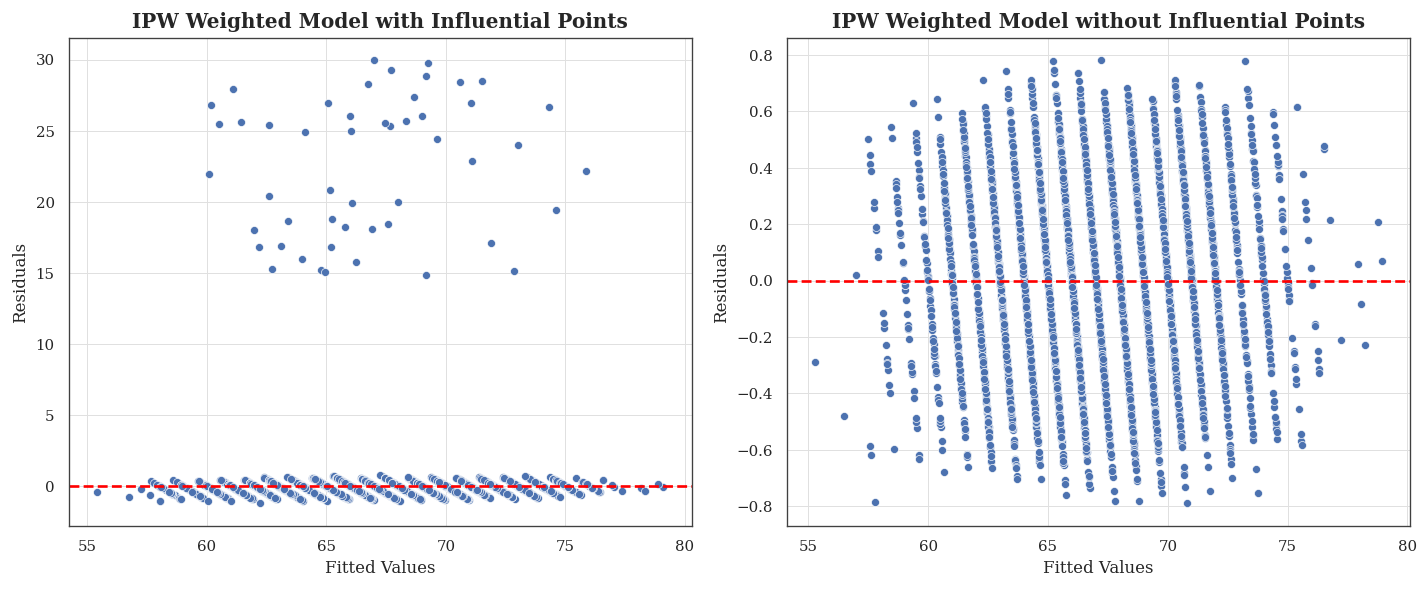

In [70]:
# compare the residuals vs fitted plots for wls with/without influential points
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
residuals_wls_no_influential = model_wls_no_influential.resid
fitted_wls_no_influential = model_wls_no_influential.fittedvalues
sns.scatterplot(x=fitted_wls, y=residuals_wls, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("IPW Weighted Model with Influential Points")
sns.scatterplot(x=fitted_wls_no_influential, y=residuals_wls_no_influential, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("IPW Weighted Model without Influential Points")
plt.tight_layout()
plt.show()

After removing the influential points, our residuals spread symmerically around zero.